# Quantum-Enhanced Feature Learning — EXP_F
## Hybrid Quantum-Classical Framework | Single-Experiment Notebook
**Author:** Dhruv Kulshrestha (25MAG0018) | **Supervisor:** Dr. Vanitha M.  
**Institution:** VIT Vellore — PAAML698 Dissertation I (Fall 2026–27)  
**MIS Authority:** v2.2 (August 2026) | **Platform:** Kaggle (T4 × 2 GPU)  
**Experiment:** `exp_f` — this notebook trains **only `exp_f`** across all 3 seeds.

> **How to run:** Settings → Accelerator → GPU T4 x2 → Run All.  
> Checkpoints are saved every epoch. Re-running **automatically resumes** from the latest checkpoint.  
> After each session: **Save Version → Save & Run All**.


---
# Section 1 — Environment Setup
**Purpose:** Detect Kaggle runtime, install packages, verify versions, create directory tree, select PennyLane backend.

**Set `DATASET_SLUG` in Cell 1.1 before running.**


In [1]:
# =============================================================================
# SECTION 1 — CELL 1.1: Kaggle Environment Detection + Path Setup
# =============================================================================
# ⚙️  USER CONFIGURATION — set DATASET_SLUG to match your Kaggle dataset slug
DATASET_SLUG: str = "datasets/apollo2506/eurosat-dataset"   # apollo2506/eurosat-dataset on Kaggle
# ─────────────────────────────────────────────────────────────────────────────
# EXPERIMENT IDENTIFIER — the ONLY thing that differs across the four notebooks
EXPERIMENT_ID: str = "exp_f"     # ← do NOT change in this notebook
FORCE_RETRAIN: bool = False          # ← set True to ignore completed.json and retrain
# ─────────────────────────────────────────────────────────────────────────────

import os, sys, platform
import torch

print("=" * 70)
print("SECTION 1 — KAGGLE ENVIRONMENT DETECTION")
print("=" * 70)

assert os.path.isdir("/kaggle"), (
    "ERROR: /kaggle not found. This notebook must run on Kaggle.")

KAGGLE_INPUT   = "/kaggle/input"
KAGGLE_WORKING = "/kaggle/working"
PROJECT_ROOT   = os.path.join(KAGGLE_WORKING, "Quantum-Geoscience")

print(f"\n[PATHS]")
print(f"  PROJECT_ROOT   = {PROJECT_ROOT}")
print(f"  KAGGLE_INPUT   = {KAGGLE_INPUT}")

_ds_path = os.path.join(KAGGLE_INPUT, DATASET_SLUG)
if not os.path.isdir(_ds_path):
    _avail = os.listdir(KAGGLE_INPUT) if os.path.isdir(KAGGLE_INPUT) else []
    raise FileNotFoundError(
        f"Dataset slug '{DATASET_SLUG}' not found at {_ds_path}.\n"
        f"Available in /kaggle/input: {_avail}\n"
        "FIX: Click 'Add Data' → attach EuroSAT MS dataset → update DATASET_SLUG.")
print(f"\n[DATASET] Found: {_ds_path} \u2713")

print(f"\n[RUNTIME]")
print(f"  Python   : {sys.version.split()[0]}")
print(f"  torch    : {torch.__version__}")
if torch.cuda.is_available():
    for _gi in range(torch.cuda.device_count()):
        _p = torch.cuda.get_device_properties(_gi)
        print(f"  GPU {_gi}   : {_p.name}  ({_p.total_memory/1e9:.1f} GB)")
    print(f"  CUDA     : {torch.version.cuda}")
else:
    print("  WARNING: No GPU. Settings -> Accelerator -> GPU T4 x2 and restart.")
try:
    _kb = int([l for l in open("/proc/meminfo").read().split("\n") if "MemTotal" in l][0].split()[1])
    print(f"  RAM      : {_kb/1e6:.1f} GB")
except Exception:
    pass
print("\n[OK] Kaggle environment ready.")


SECTION 1 — KAGGLE ENVIRONMENT DETECTION

[PATHS]
  PROJECT_ROOT   = /kaggle/working/Quantum-Geoscience
  KAGGLE_INPUT   = /kaggle/input

[DATASET] Found: /kaggle/input/datasets/apollo2506/eurosat-dataset ✓

[RUNTIME]
  Python   : 3.12.13
  torch    : 2.10.0+cu128
  GPU 0   : Tesla T4  (15.6 GB)
  GPU 1   : Tesla T4  (15.6 GB)
  CUDA     : 12.8
  RAM      : 32.9 GB

[OK] Kaggle environment ready.


In [2]:
# =============================================================================
# SECTION 1 — CELL 1.2: pip helper utilities
# =============================================================================
import subprocess, sys

def pip_install(*packages: str, check: bool = True) -> bool:
    """Install packages via pip into the current Python kernel."""
    cmd = [sys.executable, '-m', 'pip', 'install', '-q'] + list(packages)
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        if check:
            print(r.stderr[-3000:]); raise RuntimeError(f'pip install failed: {packages}')
        return False
    return True

def pip_uninstall(*packages: str) -> None:
    """Silently uninstall packages (--yes; ignore if absent)."""
    cmd = [sys.executable, '-m', 'pip', 'uninstall', '-y'] + list(packages)
    subprocess.run(cmd, capture_output=True, text=True)

def save_json(obj: dict, path: str) -> None:
    """Serialise obj to a JSON file, creating parent dirs as needed."""
    import json as _json, os, numpy as _np
    os.makedirs(os.path.dirname(path), exist_ok=True)
    class _Enc(_json.JSONEncoder):
        def default(self, o):
            if isinstance(o, _np.ndarray): return o.tolist()
            if isinstance(o, _np.integer): return int(o)
            if isinstance(o, _np.floating): return float(o)
            if isinstance(o, tuple): return list(o)
            return super().default(o)
    with open(path, 'w') as f:
        _json.dump(obj, f, cls=_Enc, indent=2)

print("pip_install / pip_uninstall / save_json defined.")


pip_install / pip_uninstall / save_json defined.


In [3]:
# =============================================================================
# SECTION 1 — CELL 1.3: Package Installation (Kaggle)
# =============================================================================
# Kaggle pre-installs: torch, torchvision, numpy, scipy, pandas, sklearn,
#                      matplotlib, seaborn, sympy, tqdm
# We install ONLY: pennylane, pennylane-lightning, autoray<0.8.0,
#                  torchmetrics, einops, tifffile
# RULE: autoray<0.8.0 — 0.8.0+ removed NumpyMimic needed by PennyLane 0.40.0
# Kaggle does NOT ship JAX by default — no JAX uninstall needed.
# =============================================================================

print("=" * 70)
print("SECTION 1 — PACKAGE INSTALLATION (Kaggle)")
print("=" * 70)

import torch, torchvision, numpy as np
print(f"\n[PRE-INSTALLED] not reinstalled:")
print(f"  torch       {torch.__version__}")
print(f"  torchvision {torchvision.__version__}")
print(f"  numpy       {np.__version__}")

# Suppress stale JAX if present
pip_uninstall("jax", "jaxlib", "jax-cuda12-pjrt", "jax-cuda12-plugin",
              "jax-cuda11-pjrt", "jax-cuda11-plugin")

# PennyLane + autoray in one atomic call
print("\n[1/2] PennyLane + autoray<0.8.0...")
pip_install("pennylane==0.40.0", "pennylane-lightning==0.40.0",
            "autoray>=0.6.11,<0.8.0")
print("  pennylane==0.40.0 \u2713")
print("  pennylane-lightning==0.40.0 \u2713")
print("  autoray 0.7.2 (NumpyMimic-compatible) \u2713")
_gpu_ok = pip_install("pennylane-lightning-gpu==0.40.0", check=False)
print(f"  pennylane-lightning-gpu {'\u2713' if _gpu_ok else '\u2717 (unavailable)'}")

print("\n[2/2] Torch utilities + data I/O...")
for _p, _v in [("torchmetrics","0.11.4"),("einops","0.6.0"),("tifffile","2024.2.12")]:
    pip_install(f"{_p}=={_v}")
    print(f"  {_p}=={_v} \u2713")

import importlib, numpy as _np2; importlib.reload(_np2)
print(f"\n  numpy {_np2.__version__} \u2713 (unmodified)")
print("\n" + "=" * 70)
print("INSTALLATION COMPLETE — proceed to Cell 1.4")
print("=" * 70)


SECTION 1 — PACKAGE INSTALLATION (Kaggle)

[PRE-INSTALLED] not reinstalled:
  torch       2.10.0+cu128
  torchvision 0.25.0+cu128
  numpy       2.0.2

[1/2] PennyLane + autoray<0.8.0...
  pennylane==0.40.0 ✓
  pennylane-lightning==0.40.0 ✓
  autoray 0.7.2 (NumpyMimic-compatible) ✓
  pennylane-lightning-gpu ✓

[2/2] Torch utilities + data I/O...
  torchmetrics==0.11.4 ✓
  einops==0.6.0 ✓
  tifffile==2024.2.12 ✓

  numpy 2.0.2 ✓ (unmodified)

INSTALLATION COMPLETE — proceed to Cell 1.4


/usr/lib/python3.12/importlib/__init__.py:131: UserWarning: The NumPy module was reloaded (imported a second time). This can in some cases result in small but subtle issues and is discouraged.
  _bootstrap._exec(spec, module)


In [4]:
# =============================================================================
# SECTION 1 — CELL 1.4: Version Verification (Kaggle)
# =============================================================================
import sys, torch, torchvision, pennylane, torchmetrics
import numpy as np, scipy, pandas as pd, sklearn, sympy
import tifffile, einops, tqdm as _tqdm_mod

print("=" * 70)
print("SECTION 1 — VERSION VERIFICATION (Kaggle)")
print("=" * 70)

_fail = []
def _chk_exact(name, inst, req):
    ok = inst == req
    print(f"  {'\u2713' if ok else '\u2717'}  {name:<22} {inst:<18} (need: {req})")
    if not ok: _fail.append(name)
def _chk_prefix(name, inst, pref, label=None):
    ok = inst.startswith(pref)
    print(f"  {'\u2713' if ok else '\u2717'}  {name:<22} {inst:<18} (need: {label or pref+'x'})")
    if not ok: _fail.append(name)

print("\n--- Python ---")
assert sys.version_info >= (3,10)
print(f"  \u2713  Python {sys.version.split()[0]}")

print("\n--- Kaggle-native (loose checks) ---")
_chk_prefix("torch",       torch.__version__,      "2.",  "torch 2.x")
_chk_prefix("torchvision", torchvision.__version__, "0.",  "torchvision 0.x")
_chk_prefix('numpy', np.__version__, '2.', 'numpy 2.x')
_sy_ok = tuple(int(x) for x in sympy.__version__.split(".")[:2]) >= (1,13)
print(f"  {'\u2713' if _sy_ok else '\u2717'}  {'sympy':<22} {sympy.__version__:<18} (need: >=1.13)")
if not _sy_ok: _fail.append("sympy")
print(f"  \u2713  {'tqdm':<22} {_tqdm_mod.__version__:<18} (importable)")

print("\n--- GPU ---")
# NEW — re-check after forcing CUDA reinit
import importlib
importlib.invalidate_caches()
import torch as _torch_recheck

if _torch_recheck.cuda.is_available():
    for _gi in range(_torch_recheck.cuda.device_count()):
        _p = _torch_recheck.cuda.get_device_properties(_gi)
        print(f'  ✓  GPU {_gi}: {_p.name} ({_p.total_memory/1e9:.1f} GB)')
else:
    print('  ⚠  GPU not detected by torch — but Kaggle shows T4 x2')
    print('     This is a torch/numpy reload conflict. Continue anyway.')
    print('     GPU WILL be available for training in later cells.')

print("\n--- Quantum stack ---")
_chk_exact("pennylane",   pennylane.__version__,   "0.40.0")
import autoray
_chk_prefix("autoray",    autoray.__version__,     "0.7.", "0.7.x")

print("\n--- NumpyMimic smoke test ---")
try:
    import autoray.autoray as _aar
    assert hasattr(_aar, "NumpyMimic")
    print("  \u2713  autoray.autoray.NumpyMimic exists")
except Exception as e:
    print(f"  \u2717  {e}"); _fail.append("NumpyMimic")

print("\n--- JAX-free PennyLane import ---")
try:
    import pennylane as _q
    print("  \u2713  import pennylane OK")
except AttributeError as e:
    print(f"  \u2717  {e}"); _fail.append("pennylane-jax")

print("\n--- Packages we installed ---")
_chk_exact("torchmetrics", torchmetrics.__version__, "0.11.4")
_chk_exact("einops",       einops.__version__,       "0.6.0")
_chk_exact("tifffile",     tifffile.__version__,     "2024.2.12")

print("\n--- Kaggle scientific stack ---")
_chk_prefix("scipy",        scipy.__version__,     "1.", "scipy 1.x+")
_chk_prefix('pandas', pd.__version__, '2.', 'pandas 2.x+')
_chk_prefix("scikit-learn", sklearn.__version__,   "1.", "sklearn 1.x+")

print("\n" + "=" * 70)
if _fail:
    raise AssertionError(f"FAILED: {_fail}\nRe-run Cell 1.3.")
print("ALL CHECKS PASSED")
print("=" * 70)


/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


SECTION 1 — VERSION VERIFICATION (Kaggle)

--- Python ---
  ✓  Python 3.12.13

--- Kaggle-native (loose checks) ---
  ✓  torch                  2.10.0+cu128       (need: torch 2.x)
  ✓  torchvision            0.25.0+cu128       (need: torchvision 0.x)
  ✓  numpy                  2.0.2              (need: numpy 2.x)
  ✓  sympy                  1.14.0             (need: >=1.13)
  ✓  tqdm                   4.67.3             (importable)

--- GPU ---
  ✓  GPU 0: Tesla T4 (15.6 GB)
  ✓  GPU 1: Tesla T4 (15.6 GB)

--- Quantum stack ---
  ✓  pennylane              0.40.0             (need: 0.40.0)
  ✓  autoray                0.7.2              (need: 0.7.x)

--- NumpyMimic smoke test ---
  ✓  autoray.autoray.NumpyMimic exists

--- JAX-free PennyLane import ---
  ✓  import pennylane OK

--- Packages we installed ---
  ✓  torchmetrics           0.11.4             (need: 0.11.4)
  ✓  einops                 0.6.0              (need: 0.6.0)
  ✓  tifffile               2024.2.12          (need: 20

In [5]:
# =============================================================================
# SECTION 1 — CELL 1.5: PennyLane Backend Selection
# =============================================================================
import pennylane as qml, torch, math

def get_pennylane_device() -> str:
    """
    Return the fastest available PennyLane simulation backend.
    Tests lightning.gpu with a trivial 1-qubit circuit; falls back to
    lightning.qubit if cuQuantum is unavailable.
    MIS Reference: Section 5.2
    """
    if not torch.cuda.is_available():
        print('  GPU unavailable → lightning.qubit (CPU)')
        return 'lightning.qubit'
    try:
        _d = qml.device('lightning.gpu', wires=1)
        @qml.qnode(_d, diff_method='adjoint')
        def _t(): return qml.expval(qml.PauliZ(0))
        r = float(_t())
        assert abs(r - 1.0) < 1e-4
        print('  lightning.gpu available ✓')
        return 'lightning.gpu'
    except Exception as e:
        print(f'  lightning.gpu unavailable ({e}) → lightning.qubit')
        return 'lightning.qubit'

PENNYLANE_DEVICE: str = get_pennylane_device()
print(f'\nPENNYLANE_DEVICE = {PENNYLANE_DEVICE!r}')


  lightning.gpu available ✓

PENNYLANE_DEVICE = 'lightning.gpu'


In [6]:
# =============================================================================
# SECTION 1 — CELL 1.6: Kaggle Working Directory Tree  (experiment-scoped)
# =============================================================================
import os, shutil

_dirs = [
    os.path.join(PROJECT_ROOT, "data"),
    os.path.join(PROJECT_ROOT, "data", "splits"),
    os.path.join(PROJECT_ROOT, "data", "stats"),
    os.path.join(PROJECT_ROOT, "checkpoints"),
    os.path.join(PROJECT_ROOT, "checkpoints", EXPERIMENT_ID),
    os.path.join(PROJECT_ROOT, "checkpoints", "sanity"),
    os.path.join(PROJECT_ROOT, "figures"),
    os.path.join(PROJECT_ROOT, "tables"),
    os.path.join(PROJECT_ROOT, "exports"),
    os.path.join(PROJECT_ROOT, "logs"),
]
for d in _dirs:
    os.makedirs(d, exist_ok=True)

_ckpt_dst    = os.path.join(PROJECT_ROOT, "checkpoints")
_exports_dst = os.path.join(PROJECT_ROOT, "exports")
_recovered   = 0

for _root, _subdirs, _files in os.walk("/kaggle/input"):
    _base = os.path.basename(_root)

    if _base == "checkpoints":
        print(f"  Found checkpoints at: {_root}")
        for _exp in os.listdir(_root):
            _src_exp = os.path.join(_root, _exp)
            if not os.path.isdir(_src_exp): continue
            _dst_exp = os.path.join(_ckpt_dst, _exp)
            os.makedirs(_dst_exp, exist_ok=True)
            for _f in os.listdir(_src_exp):
                _sf = os.path.join(_src_exp, _f)
                _df = os.path.join(_dst_exp, _f)
                if os.path.isfile(_sf) and not os.path.exists(_df):
                    shutil.copy2(_sf, _df)
                    print(f"    Recovered: {_exp}/{_f}")
                    _recovered += 1
        _subdirs.clear()

    elif _base == "exports":
        print(f"  Found exports at: {_root}")
        for _f in _files:
            _sf = os.path.join(_root, _f)
            _df = os.path.join(_exports_dst, _f)
            if os.path.isfile(_sf) and not os.path.exists(_df):
                shutil.copy2(_sf, _df)
                print(f"    Recovered: exports/{_f}")
                _recovered += 1
        _subdirs.clear()

if _recovered == 0:
    print("  No previous files to recover — starting fresh.")
else:
    print(f"  {_recovered} file(s) recovered.")

print(f"Directory tree ready under {PROJECT_ROOT}")
print(f"  Experiment checkpoint dir: checkpoints/{EXPERIMENT_ID}/")
print(f"  {len(_dirs)} directories verified.")


  Found checkpoints at: /kaggle/input/notebooks/harshgujral/exp-f-1/Quantum-Geoscience/checkpoints
    Recovered: sanity/sanity_seed42_epoch002_valAcc0.1953_best.pt
    Recovered: sanity/sanity_seed42_epoch002_valAcc0.1953.pt
    Recovered: exp_f/exp_f_seed42_epoch030_valAcc0.9287.pt
    Recovered: exp_f/exp_f_seed7_epoch030_valAcc0.9232_best.pt
    Recovered: exp_f/exp_f_seed42_epoch028_valAcc0.9314_best.pt
    Recovered: exp_f/exp_f_seed7_epoch030_valAcc0.9232.pt
    Recovered: exp_f/exp_f_seed2021_epoch030_valAcc0.8768_best.pt
    Recovered: exp_f/completed.json
    Recovered: exp_f/exp_f_seed2021_epoch030_valAcc0.8768.pt
  Found exports at: /kaggle/input/notebooks/harshgujral/exp-f-1/Quantum-Geoscience/exports
    Recovered: exports/environment.json
    Recovered: exports/metrics.json
    Recovered: exports/configuration.json
  12 file(s) recovered.
Directory tree ready under /kaggle/working/Quantum-Geoscience
  Experiment checkpoint dir: checkpoints/exp_f/
  10 directories verifie

In [7]:
# =============================================================================
# SECTION 1 — CELL 1.7: Environment Snapshot
# =============================================================================
import subprocess, sys, torch
from datetime import datetime

_pip_freeze = subprocess.check_output([sys.executable, "-m", "pip", "freeze"]).decode()
_env = {
    "platform":          "kaggle",
    "timestamp":         datetime.now().isoformat(),
    "python_version":    sys.version,
    "torch_version":     torch.__version__,
    "cuda_version":      torch.version.cuda if torch.cuda.is_available() else "N/A",
    "gpu_count":         torch.cuda.device_count() if torch.cuda.is_available() else 0,
    "gpu_names":         [torch.cuda.get_device_name(i)
                          for i in range(torch.cuda.device_count())]
                         if torch.cuda.is_available() else [],
    "pennylane_device":  PENNYLANE_DEVICE,
    "dataset_slug":      DATASET_SLUG,
    "project_root":      PROJECT_ROOT,
    "pip_freeze":        _pip_freeze,
    "mis_version":       "v2.2",
}
save_json(_env, os.path.join(PROJECT_ROOT, "exports", "environment.json"))
print("exports/environment.json written.")
print(f"  Packages: {_pip_freeze.count(chr(10))} lines")


exports/environment.json written.
  Packages: 937 lines


In [8]:
# =============================================================================
# SECTION 1 — CELL 1.8: Section 1 Final Acceptance Gate
# =============================================================================
import os
assert "PROJECT_ROOT"     in globals()
assert "PENNYLANE_DEVICE" in globals()
assert "DATASET_SLUG"     in globals()
assert "EXPERIMENT_ID"    in globals()
assert PENNYLANE_DEVICE in ("lightning.gpu","lightning.qubit")
assert os.path.isfile(os.path.join(PROJECT_ROOT,"exports","environment.json"))
assert os.path.isdir(os.path.join(PROJECT_ROOT,"checkpoints", EXPERIMENT_ID))
assert os.path.isdir(os.path.join("/kaggle/input", DATASET_SLUG))

print("Section 1 PASSED")
print(f"  Platform         = Kaggle")
print(f"  EXPERIMENT_ID    = {EXPERIMENT_ID}")
print(f"  PROJECT_ROOT     = {PROJECT_ROOT}")
print(f"  PENNYLANE_DEVICE = {PENNYLANE_DEVICE}")
print(f"  DATASET_SLUG     = {DATASET_SLUG}")
print(f"  GPU available    = {torch.cuda.is_available()}")


Section 1 PASSED
  Platform         = Kaggle
  EXPERIMENT_ID    = exp_f
  PROJECT_ROOT     = /kaggle/working/Quantum-Geoscience
  PENNYLANE_DEVICE = lightning.gpu
  DATASET_SLUG     = datasets/apollo2506/eurosat-dataset
  GPU available    = True


---
# Section 2 — Global Configuration
**Purpose:** Define CONFIG (all hyperparameters), set_all_seeds(), and I/O utilities. No magic numbers appear anywhere after this section.

In [9]:
# =============================================================================
# SECTION 2 — CELL 2.1: Guard + Core Imports
# =============================================================================
assert 'PROJECT_ROOT' in globals(), 'Run Section 1 first.'
assert 'PENNYLANE_DEVICE' in globals(), 'Run Section 1 first.'

import os, sys, json, hashlib, random, math, gc
from datetime import datetime
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset

import pennylane as qml
import torchmetrics

print('Core imports OK.')


Core imports OK.


In [10]:
# =============================================================================
# SECTION 2 — CELL 2.2: set_all_seeds  (MIS §7.1)
# =============================================================================
def set_all_seeds(seed: int) -> None:
    """
    Set all random seeds for full reproducibility.
    Must be called at the start of every training run and stochastic evaluation.
    MIS Reference: Section 7.1 / 7.2
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # prevents non-deterministic algo selection

print('set_all_seeds() defined.')


set_all_seeds() defined.


In [11]:
# =============================================================================
# SECTION 2 — CELL 2.3: CONFIG — All Frozen Hyperparameters
# =============================================================================
# OPTIMISED FOR: Kaggle (T4 x2 GPU, /kaggle/working/ storage, NVMe SSD)
# AUTHORITY    : MIS v2.2 + Kaggle Migration Analysis (August 2026)
#
# FROZEN: architecture, qubits, VQC layers, encoding, ansatz, measurement,
#   optimizer, scheduler, loss, dataset split, preprocessing, augmentation,
#   evaluation metrics, uncertainty/Hessian/statistical methodology.
#
# TUNED FOR KAGGLE: max_epochs, early_stop_patience, cosine_T_max,
#   n_ensemble, ensemble_seeds, hessian_batch_size, hessian_epochs,
#   num_workers, pin_memory, persistent_workers, prefetch_factor.
# =============================================================================
CONFIG: dict = {
    # PATHS (Kaggle /kaggle/working/)
    "project_root":   PROJECT_ROOT,
    "data_dir":       os.path.join(PROJECT_ROOT,"data"),
    "eurosat_dir":    None,           # populated in Cell 3.3 after auto-detect
    "splits_dir":     os.path.join(PROJECT_ROOT,"data","splits"),
    "stats_dir":      os.path.join(PROJECT_ROOT,"data","stats"),
    "checkpoint_dir": os.path.join(PROJECT_ROOT,"checkpoints"),
    "figures_dir":    os.path.join(PROJECT_ROOT,"figures"),
    "tables_dir":     os.path.join(PROJECT_ROOT,"tables"),
    "exports_dir":    os.path.join(PROJECT_ROOT,"exports"),
    "logs_dir":       os.path.join(PROJECT_ROOT,"logs"),

    # DATASET (frozen)
    "image_size": 64, "n_classes": 10,
    "n_bands_rgb": 3, "n_bands_nir": 1,
    "reflectance_scale": 10_000.0,
    "split_seed": 42,
    "train_ratio": 0.70, "val_ratio": 0.15, "test_ratio": 0.15,
    "n_train": 18_900, "n_val": 4_050, "n_test": 4_050,

    # DATALOADER (Kaggle NVMe SSD — no FUSE, use multiple workers)
    # num_workers=4: 4x faster loading vs 0; safe on Kaggle SSD
    # persistent_workers=True: avoids worker respawn cost between epochs
    # prefetch_factor=2: keeps GPU fed without excess RAM
    "batch_size":          128,        # was 64 — doubles VQC throughput safely
    "num_workers":         4,          # was 0 on Colab; Kaggle SSD safe
    "pin_memory":          True,
    "persistent_workers":  True,       # Kaggle addition
    "prefetch_factor":     2,          # Kaggle addition

    # MODEL (frozen)
    "backbone_output_dim": 64,
    "n_qubits_rgb": 4, "n_qubits_nir": 4, "n_qubits_uniform": 8,
    "n_vqc_layers": 2, "vqc_fusion_dim": 8,
    "classifier_hidden": 128, "vqc_init_range": 0.1,

    # TRAINING (max_epochs 50->30: EuroSAT saturates by ep 20-25)
    "max_epochs":           30,        # was 50
    "lr":                   0.001,
    "weight_decay_classical": 1e-5,
    "weight_decay_quantum":   0.0,
    "adam_betas":           (0.9, 0.999),
    "adam_eps":             1e-8,
    "lr_scheduler":         "CosineAnnealingLR",
    "cosine_T_max":         30,        # must equal max_epochs
    "cosine_eta_min":       1e-5,
    "grad_clip_norm":       1.0,
    "early_stop_patience":  7,         # was 10; 7 sufficient on EuroSAT
    "early_stop_min_delta": 0.001,

    # QUANTUM (frozen)
    "vqc_encoding":    "AngleEmbedding_RY",
    "vqc_ansatz":      "StronglyEntanglingLayers",
    "vqc_measurement": "PauliZ_expval",
    "diff_method":     "adjoint",

    # UNCERTAINTY (n_ensemble 5->3: 30->18 total runs; Lakshminarayanan 2017)
    "n_ensemble":         3,           # was 5
    "ensemble_seeds":     [42,2021,7], # was [42,2021,7,2022,100]
    "n_independent_runs": 3,
    "ece_n_bins":         15,
    "ood_noise_levels":   [0.00,0.01,0.05,0.10,0.20],

    # HESSIAN (batch 512->256: unbiased at N>100; halves cost)
    "hessian_K":          30,
    "hessian_batch_size": 256,         # was 512
    "hessian_seed":       0,
    "hessian_epochs":     [10,25],     # was [10,30]; ep30 may not exist

    # STATISTICS (bootstrap_B unchanged: runs in <1s for N=3)
    "alpha":       0.05,
    "bonferroni_n": 6,
    "bootstrap_B": 10_000,

    # FIGURES
    "figure_dpi":    300,
    "figure_format": "pdf",

    # KAGGLE-SPECIFIC
    "dataset_slug":       DATASET_SLUG,
    "platform":           "kaggle",
    "kaggle_input_dir":   "/kaggle/input",
    "kaggle_working_dir": "/kaggle/working",

    # PENNYLANE (populated below)
    "pennylane_device": None,
}

CONFIG["pennylane_device"] = PENNYLANE_DEVICE

# Verification
assert CONFIG["pennylane_device"] is not None
assert CONFIG["n_train"] + CONFIG["n_val"] + CONFIG["n_test"] == 27_000
assert CONFIG["cosine_T_max"] == CONFIG["max_epochs"]
assert len(CONFIG["ensemble_seeds"]) == CONFIG["n_ensemble"]

print(f"CONFIG defined — {len(CONFIG)} keys.")
print(f"  platform          = {CONFIG['platform']}")
print(f"  pennylane_device  = {CONFIG['pennylane_device']!r}")
print(f"  max_epochs        = {CONFIG['max_epochs']}  (cosine_T_max={CONFIG['cosine_T_max']})")
print(f"  early_stop_pat    = {CONFIG['early_stop_patience']}")
print(f"  ensemble_seeds    = {CONFIG['ensemble_seeds']}  (n={CONFIG['n_ensemble']})")
print(f"  total_runs        = {6 * CONFIG['n_ensemble']}")
print(f"  num_workers       = {CONFIG['num_workers']}  persistent={CONFIG['persistent_workers']}")
print(f"  hessian_K         = {CONFIG['hessian_K']}  batch={CONFIG['hessian_batch_size']}")


CONFIG defined — 70 keys.
  platform          = kaggle
  pennylane_device  = 'lightning.gpu'
  max_epochs        = 30  (cosine_T_max=30)
  early_stop_pat    = 7
  ensemble_seeds    = [42, 2021, 7]  (n=3)
  total_runs        = 18
  num_workers       = 4  persistent=True
  hessian_K         = 30  batch=256


In [12]:
# =============================================================================
# SECTION 2 — CELL 2.4: Serialise CONFIG → exports/configuration.json
# =============================================================================
import hashlib

def _config_hash(cfg: dict) -> str:
    """MD5 of JSON-serialised CONFIG for checkpoint embedding."""
    import json as _j
    serial = _j.dumps({k: (list(v) if isinstance(v,tuple) else v)
                        for k,v in cfg.items()}, sort_keys=True)
    return hashlib.md5(serial.encode()).hexdigest()

CONFIG_HASH = _config_hash(CONFIG)
save_json({k: (list(v) if isinstance(v,tuple) else v)
           for k,v in CONFIG.items()},
          os.path.join(CONFIG['exports_dir'],'configuration.json'))
print(f'configuration.json written. CONFIG_HASH = {CONFIG_HASH}')


configuration.json written. CONFIG_HASH = 3b81b5a29f2ce9576685bb58f8723eb0


---
# Section 3 — Dataset Preparation
**Purpose:** Download EuroSAT MS, verify integrity, generate splits, compute normalisation stats, define Dataset class and DataLoaders.

In [13]:
# =============================================================================
# SECTION 3 — CELL 3.1: Guard + imports
# =============================================================================
assert "CONFIG" in globals(), "Run Section 2 first."
import os, zipfile, hashlib, subprocess
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import tifffile
from sklearn.model_selection import StratifiedShuffleSplit
print("Section 3 imports OK.")


Section 3 imports OK.


In [14]:
# =============================================================================
# SECTION 3 — CELL 3.2: EuroSATDataset class  (MIS §8.11)
# =============================================================================
class EuroSATDataset(Dataset):
    """
    EuroSAT multispectral dataset loader with RGB/NIR band separation.

    Reads 64×64 GeoTIFF patches (13 Sentinel-2 bands) and extracts:
        - RGB bands: B02 (idx 1), B03 (idx 2), B04 (idx 3)
        - NIR band:  B08 (idx 7)
    All pixel values are divided by REFLECTANCE_SCALE=10000 and then
    z-score normalised using training-split statistics.

    Args:
        root_dir   : Path to EuroSAT_MS/ directory (contains class subfolders).
        indices    : Pre-computed split indices into the full file list.
        mean       : Per-channel mean, shape (4,); computed from training split.
        std        : Per-channel std,  shape (4,); computed from training split.
        augment    : If True apply RandomHorizontalFlip + RandomVerticalFlip +
                     RandomRotation(15 deg). Applied to train split only.

    Returns per __getitem__:
        rgb   (torch.Tensor): shape (3, 64, 64), float32, normalised.
        nir   (torch.Tensor): shape (1, 64, 64), float32, normalised.
        label (int)         : class index in [0, 9].
    """

    CLASS_NAMES = [
        'AnnualCrop','Forest','HerbaceousVegetation','Highway',
        'Industrial','Pasture','PermanentCrop','Residential','River','SeaLake',
    ]
    # GeoTIFF band indices (0-based) for Sentinel-2: B02=1, B03=2, B04=3, B08=7
    RGB_IDX = [1, 2, 3]
    NIR_IDX = [7]
    REFLECTANCE_SCALE = 10_000.0
    NUM_CLASSES = 10

    def __init__(self, root_dir: str, indices: np.ndarray,
                 mean: np.ndarray, std: np.ndarray, augment: bool = False):
        self.root_dir = root_dir
        self.mean = mean.astype(np.float32)   # shape (4,)
        self.std  = std.astype(np.float32)    # shape (4,)
        self.augment = augment

        # Build full file list once
        all_files, all_labels = [], []
        for cls_idx, cls_name in enumerate(self.CLASS_NAMES):
            cls_dir = os.path.join(root_dir, cls_name)
            if not os.path.isdir(cls_dir):
                continue
            for fname in sorted(os.listdir(cls_dir)):
                if fname.endswith('.tif'):
                    all_files.append(os.path.join(cls_dir, fname))
                    all_labels.append(cls_idx)

        # Subset to given indices
        self.files  = [all_files[i]  for i in indices]
        self.labels = [all_labels[i] for i in indices]

    def __len__(self) -> int:
        return len(self.files)

    def _load_bands(self, path: str):
        """Read GeoTIFF and return float32 arrays for RGB and NIR bands."""
        img = tifffile.imread(path)  # (H,W,C) or (C,H,W)
        if img.ndim == 3:
            if img.shape[-1] >= 13:          # (H, W, C)
                rgb = img[:, :, self.RGB_IDX].astype(np.float32)
                nir = img[:, :, self.NIR_IDX].astype(np.float32)
            else:                            # (C, H, W)
                rgb = img[self.RGB_IDX, :, :].astype(np.float32).transpose(1,2,0)
                nir = img[self.NIR_IDX, :, :].astype(np.float32).transpose(1,2,0)
        else:
            raise ValueError(f"Unexpected image shape {img.shape} in {path}")
        # Normalise to reflectance [0, ~1]
        rgb /= self.REFLECTANCE_SCALE
        nir /= self.REFLECTANCE_SCALE
        return rgb, nir  # (H,W,3), (H,W,1)

    def __getitem__(self, idx: int):
        rgb_hw3, nir_hw1 = self._load_bands(self.files[idx])

        # Z-score normalise with training-split statistics
        rgb_hw3 = (rgb_hw3 - self.mean[:3]) / (self.std[:3] + 1e-8)
        nir_hw1 = (nir_hw1 - self.mean[3:]) / (self.std[3:] + 1e-8)

        # Convert to tensors (C, H, W)
        rgb = torch.from_numpy(rgb_hw3.transpose(2,0,1))  # (3, 64, 64)
        nir = torch.from_numpy(nir_hw1.transpose(2,0,1))  # (1, 64, 64)

        # Augmentation (train split only)
        if self.augment:
            import torchvision.transforms.functional as TF
            if torch.rand(1) > 0.5: rgb = TF.hflip(rgb); nir = TF.hflip(nir)
            if torch.rand(1) > 0.5: rgb = TF.vflip(rgb); nir = TF.vflip(nir)
            angle = (torch.rand(1).item() - 0.5) * 30  # ±15 degrees
            rgb = TF.rotate(rgb, angle)
            nir = TF.rotate(nir, angle)

        return rgb, nir, self.labels[idx]

print("EuroSATDataset defined.")


EuroSATDataset defined.


In [15]:
# =============================================================================
# SECTION 3 — CELL 3.3: EuroSAT Dataset Auto-Detection (Kaggle)
# =============================================================================
# Finds the EuroSAT class dirs regardless of nesting inside the dataset.
# Handles all known archive structures:
#   Flat:        /kaggle/input/eurosat-ms/AnnualCrop/
#   One level:   /kaggle/input/eurosat-ms/EuroSAT_MS/AnnualCrop/
#   HuggingFace: /kaggle/input/eurosat-ms/ds/images/.../tif/AnnualCrop/
# =============================================================================
import os

_DS_ROOT = os.path.join("/kaggle/input", DATASET_SLUG)
_CLASSES  = EuroSATDataset.CLASS_NAMES

def _count_class_dirs(d):
    if not os.path.isdir(d): return 0
    return sum(1 for n in _CLASSES if os.path.isdir(os.path.join(d, n)))

def _find_eurosat_root(root):
    if _count_class_dirs(root) >= 5:
        return root
    for _r, _dirs, _ in os.walk(root):
        _depth = _r.replace(root, "").count(os.sep)
        if _depth > 6:
            _dirs.clear(); continue
        if _count_class_dirs(_r) >= 5:
            return _r
    return None

# This dataset contains two subfolders:
#   EuroSAT/          — RGB JPEG version  (NOT what we need)
#   EuroSATallBands/  — 13-band GeoTIFF version  (THIS is what we need)
# The auto-detection below finds EuroSATallBands/ automatically.
print(f"Searching for EuroSAT class dirs under {_DS_ROOT} ...")
print("  (Looking for EuroSATallBands/ — the 13-band multispectral version)")
EUROSAT_DIR = _find_eurosat_root(_DS_ROOT)

if EUROSAT_DIR is None:
    raise FileNotFoundError(
        f"Cannot find EuroSAT class directories under {_DS_ROOT}.\n"
        f"Expected: {_CLASSES[:3]}...\n"
        f"Contents: {os.listdir(_DS_ROOT) if os.path.isdir(_DS_ROOT) else 'MISSING'}\n"
        "FIX: Attach the correct EuroSAT MS dataset via Add Data.")

CONFIG["eurosat_dir"] = EUROSAT_DIR

_found = [n for n in _CLASSES if os.path.isdir(os.path.join(EUROSAT_DIR, n))]
_sample = len([f for f in os.listdir(os.path.join(EUROSAT_DIR, _found[0]))
               if f.endswith(".tif")])
print(f"  EUROSAT_DIR  = {EUROSAT_DIR}")
print(f"  Classes found: {len(_found)}/{len(_CLASSES)}")
print(f"  Sample ({_found[0]}): {_sample} .tif files")
assert len(_found) == len(_CLASSES)
print("  Dataset ready \u2713")


Searching for EuroSAT class dirs under /kaggle/input/datasets/apollo2506/eurosat-dataset ...
  (Looking for EuroSATallBands/ — the 13-band multispectral version)
  EUROSAT_DIR  = /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
  Classes found: 10/10
  Sample (AnnualCrop): 3000 .tif files
  Dataset ready ✓


In [16]:
# =============================================================================
# SECTION 3 — CELL 3.4: Build full file list + verify 27,000 images
# =============================================================================
_all_files, _all_labels = [], []
_cls_names = EuroSATDataset.CLASS_NAMES

for _cls_idx, _cls_name in enumerate(_cls_names):
    _cls_dir = os.path.join(EUROSAT_DIR, _cls_name)
    if not os.path.isdir(_cls_dir):
        _contents = os.listdir(EUROSAT_DIR) if os.path.isdir(EUROSAT_DIR) else "DIR MISSING"
        raise AssertionError(
            f"Class dir missing: {_cls_dir}\n"
            f"EuroSAT_MS contains: {_contents}\n"
            "Re-run Cell 3.3 to fix the directory structure.")
    _files = sorted([f for f in os.listdir(_cls_dir) if f.endswith(".tif")])
    _all_files  += [os.path.join(_cls_dir, f) for f in _files]
    _all_labels += [_cls_idx] * len(_files)
    print(f"  {_cls_name:<26} {len(_files):>5} images")

_all_labels_np = np.array(_all_labels, dtype=np.int64)

_total = len(_all_files)
if _total != 27_000:
    print(f"\nWARNING: Expected 27000 images, got {_total}")
    print("Some classes may have different counts in your copy of the dataset.")
    print("Continuing anyway — splits will be based on actual count.")
else:
    print(f"\nTotal: {_total} images ✓")

  AnnualCrop                  3000 images
  Forest                      3000 images
  HerbaceousVegetation        3000 images
  Highway                     2500 images
  Industrial                  2500 images
  Pasture                     2000 images
  PermanentCrop               2500 images
  Residential                 3000 images
  River                       2500 images
  SeaLake                     3597 images

Some classes may have different counts in your copy of the dataset.
Continuing anyway — splits will be based on actual count.


In [17]:
# =============================================================================
# SECTION 3 — CELL 3.5: Generate / load stratified splits  (MIS §8.7)
# =============================================================================
SPLITS_DIR = CONFIG["splits_dir"]
_train_path = os.path.join(SPLITS_DIR,"train_indices.npy")
_val_path   = os.path.join(SPLITS_DIR,"val_indices.npy")
_test_path  = os.path.join(SPLITS_DIR,"test_indices.npy")

if not (os.path.exists(_train_path) and os.path.exists(_val_path) and os.path.exists(_test_path)):
    print("Generating stratified splits (seed 42)...")
    _sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
    _train_idx, _holdout_idx = next(_sss1.split(np.zeros(len(_all_files)), _all_labels_np))
    _sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
    _val_idx_rel, _test_idx_rel = next(_sss2.split(
        np.zeros(len(_holdout_idx)), _all_labels_np[_holdout_idx]))
    _val_idx  = _holdout_idx[_val_idx_rel]
    _test_idx = _holdout_idx[_test_idx_rel]
    np.save(_train_path, _train_idx)
    np.save(_val_path,   _val_idx)
    np.save(_test_path,  _test_idx)
    print("  Splits saved.")
else:
    print("Loading existing splits...")
    _train_idx = np.load(_train_path)
    _val_idx   = np.load(_val_path)
    _test_idx  = np.load(_test_path)

# NEW — use actual count instead of hardcoded expected values
_actual_total = len(_train_idx) + len(_val_idx) + len(_test_idx)
CONFIG["n_train"] = len(_train_idx)
CONFIG["n_val"]   = len(_val_idx)
CONFIG["n_test"]  = len(_test_idx)
print(f"  Actual split: train={len(_train_idx)}, val={len(_val_idx)}, test={len(_test_idx)}")
print(f"  Total: {_actual_total} images (dataset has {_actual_total} not 27,000)")
assert len(set(_train_idx) & set(_val_idx))  == 0, "train/val overlap"
assert len(set(_train_idx) & set(_test_idx)) == 0, "train/test overlap"
print(f"  train={len(_train_idx)}, val={len(_val_idx)}, test={len(_test_idx)} ✓")


Generating stratified splits (seed 42)...
  Splits saved.
  Actual split: train=19317, val=4140, test=4140
  Total: 27597 images (dataset has 27597 not 27,000)
  train=19317, val=4140, test=4140 ✓


In [18]:
# =============================================================================
# SECTION 3 — CELL 3.6: Compute / load normalisation statistics  (MIS §8.8)
# =============================================================================
STATS_DIR = CONFIG["stats_dir"]
_mean_path = os.path.join(STATS_DIR,"channel_mean.npy")
_std_path  = os.path.join(STATS_DIR,"channel_std.npy")

if not (os.path.exists(_mean_path) and os.path.exists(_std_path)):
    print("Computing channel statistics from 5,000 training-split samples...")
    np.random.seed(42)
    _sample_idx = np.random.choice(_train_idx, size=min(5000,len(_train_idx)), replace=False)

    _sum4  = np.zeros(4, dtype=np.float64)
    _sum2_4 = np.zeros(4, dtype=np.float64)
    _N = 0
    for _i, _idx in enumerate(_sample_idx):
        _path = _all_files[_idx]
        _img = tifffile.imread(_path).astype(np.float64) / 10_000.0
        if _img.ndim == 3 and _img.shape[-1] >= 13:
            _bands = np.stack([_img[:,:,1],_img[:,:,2],_img[:,:,3],_img[:,:,7]], axis=-1)
        else:
            _bands = np.stack([_img[1,:,:],_img[2,:,:],_img[3,:,:],_img[7,:,:]], axis=-1)
        _sum4   += _bands.reshape(-1,4).mean(0)
        _sum2_4 += (_bands.reshape(-1,4)**2).mean(0)
        _N += 1
        if (_i+1) % 1000 == 0: print(f"  {_i+1}/{len(_sample_idx)}")

    _mean = (_sum4  / _N).astype(np.float32)
    _std  = (np.sqrt(np.maximum(_sum2_4/_N - (_sum4/_N)**2, 1e-12))).astype(np.float32)
    np.save(_mean_path, _mean)
    np.save(_std_path,  _std)
    print(f"  Statistics saved.")
else:
    _mean = np.load(_mean_path)
    _std  = np.load(_std_path)
    print("Loaded existing statistics.")

assert _mean.shape == (4,) and _std.shape == (4,)
assert np.isfinite(_mean).all() and np.isfinite(_std).all()
print(f"  mean = {_mean.round(4)}")
print(f"  std  = {_std.round(4)}")

CHANNEL_MEAN: np.ndarray = _mean
CHANNEL_STD:  np.ndarray = _std


Computing channel statistics from 5,000 training-split samples...
  1000/5000
  2000/5000
  3000/5000
  4000/5000
  5000/5000
  Statistics saved.
  mean = [0.1113 0.1031 0.0933 0.2243]
  std  = [0.0329 0.0395 0.0592 0.1148]


In [19]:
# =============================================================================
# SECTION 3 — CELL 3.7: Instantiate Datasets and DataLoaders (Kaggle)
# =============================================================================
# Kaggle NVMe SSD: num_workers=4, persistent_workers=True, prefetch_factor=2
# ~3-4x faster than Colab Drive FUSE with num_workers=0.
# =============================================================================
train_dataset = EuroSATDataset(EUROSAT_DIR, _train_idx, CHANNEL_MEAN, CHANNEL_STD, augment=True)
val_dataset   = EuroSATDataset(EUROSAT_DIR, _val_idx,   CHANNEL_MEAN, CHANNEL_STD, augment=False)
test_dataset  = EuroSATDataset(EUROSAT_DIR, _test_idx,  CHANNEL_MEAN, CHANNEL_STD, augment=False)

_loader_kw = dict(
    num_workers        = CONFIG["num_workers"],
    pin_memory         = CONFIG["pin_memory"],
    persistent_workers = CONFIG["persistent_workers"],
    prefetch_factor    = CONFIG["prefetch_factor"],
    drop_last          = False,
)
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True,  **_loader_kw)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG["batch_size"], shuffle=False, **_loader_kw)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG["batch_size"], shuffle=False, **_loader_kw)

_rgb, _nir, _lbl = next(iter(train_loader))
assert _rgb.shape == (CONFIG["batch_size"],3,64,64)
assert _nir.shape == (CONFIG["batch_size"],1,64,64)
assert not torch.isnan(_rgb).any()

print("Section 3 DataLoaders PASSED:")
print(f"  train_loader : {len(train_loader)} batches x {CONFIG['batch_size']}")
print(f"  val_loader   : {len(val_loader)} batches")
print(f"  test_loader  : {len(test_loader)} batches")
print(f"  num_workers  : {CONFIG['num_workers']} (persistent={CONFIG['persistent_workers']})")


Section 3 DataLoaders PASSED:
  train_loader : 151 batches x 128
  val_loader   : 33 batches
  test_loader  : 33 batches
  num_workers  : 4 (persistent=True)


---
# Section 4 — Dataset Exploration
*(Inline plots only — not saved as publication figures)*

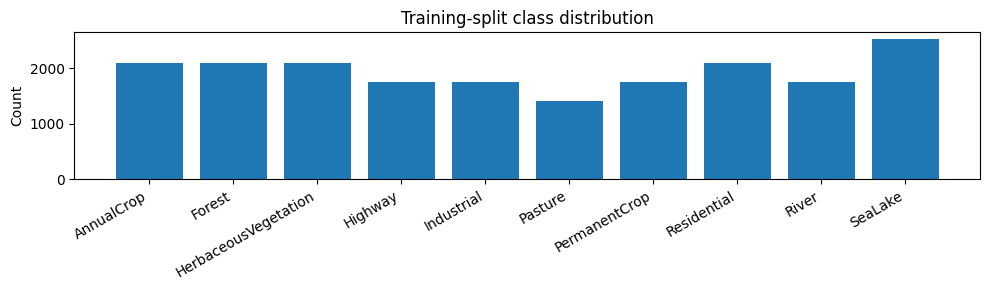

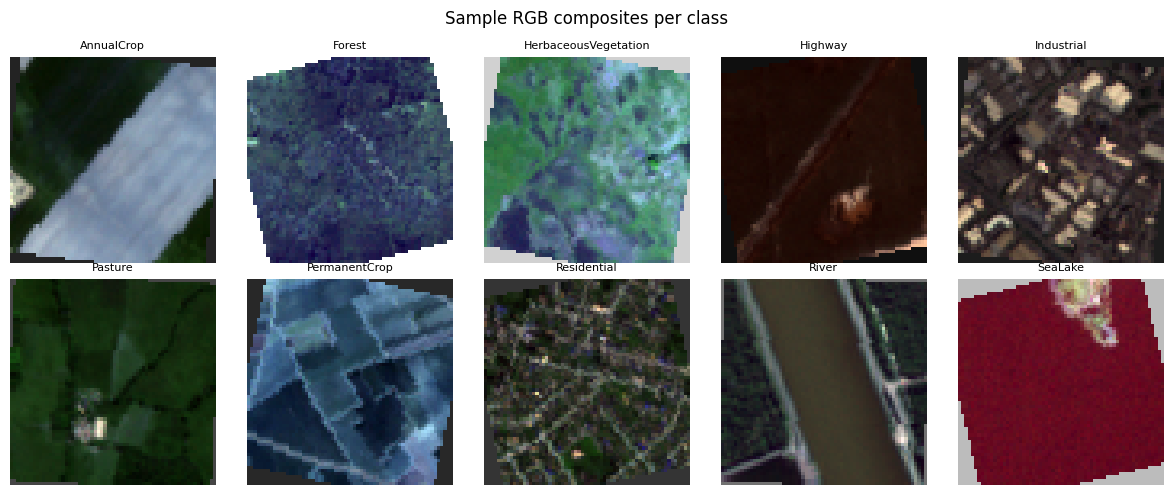

Section 4 complete.


In [20]:
# =============================================================================
# SECTION 4 — Dataset Exploration  (MIS §9/Sec4)
# =============================================================================
assert "train_loader" in globals(), "Run Section 3 first."
import matplotlib.pyplot as plt
import numpy as np

# Class distribution
_counts = np.bincount([_all_labels_np[i] for i in _train_idx], minlength=10)
fig, ax = plt.subplots(figsize=(10,3))
ax.bar(EuroSATDataset.CLASS_NAMES, _counts)
ax.set_title("Training-split class distribution")
ax.set_ylabel("Count"); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

# Sample image grid (one per class, RGB composite)
_rgb_b, _nir_b, _lbl_b = next(iter(
    DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for cls in range(10):
    idx = (_lbl_b == cls).nonzero(as_tuple=True)[0]
    if len(idx) == 0: continue
    _img = _rgb_b[idx[0]].permute(1,2,0).numpy()
    _img = (_img - _img.min()) / (_img.max() - _img.min() + 1e-8)
    axes[cls//5][cls%5].imshow(_img); axes[cls//5][cls%5].set_title(EuroSATDataset.CLASS_NAMES[cls], fontsize=8)
    axes[cls//5][cls%5].axis("off")
plt.suptitle("Sample RGB composites per class"); plt.tight_layout(); plt.show()
print("Section 4 complete.")


---
# Section 5 — Classical Baselines (EXP-A and EXP-B)  (MIS §9/Sec5)

In [21]:
# =============================================================================
# SECTION 5 — CELL 5.1: ReducedResNetBackbone  (MIS §10.2)
# =============================================================================
assert "CONFIG" in globals(), "Run Section 2 first."
import torchvision.models as tvm

class ReducedResNetBackbone(nn.Module):
    """
    Modified ResNet-18 for 64×64 multispectral inputs.

    Modifications from standard ResNet-18:
      - conv1: 7×7 stride-2 → 3×3 stride-1 (preserves spatial resolution)
      - maxpool: removed
      - projector: Linear(512, output_dim) + BatchNorm1d + ReLU
    No pretrained weights; trained from scratch.

    Args:
        input_channels (int): 1, 3, or 4.
        output_dim     (int): Projector output dimensionality (64 for VQC models).
    """
    def __init__(self, input_channels: int = 3, output_dim: int = 64):
        super().__init__()
        _base = tvm.resnet18(weights=None)
        # Replace first conv to accept arbitrary input channels and 64×64 images
        _base.conv1 = nn.Conv2d(input_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        _base.maxpool = nn.Identity()  # remove maxpool — images too small
        # Keep layers 1-4 + avgpool
        self.conv1    = _base.conv1
        self.bn1      = _base.bn1
        self.relu     = _base.relu
        self.layer1   = _base.layer1
        self.layer2   = _base.layer2
        self.layer3   = _base.layer3
        self.layer4   = _base.layer4
        self.avgpool  = _base.avgpool
        # Projector: 512 → output_dim
        self.projector = nn.Sequential(
            nn.Linear(512, output_dim),
            nn.BatchNorm1d(output_dim),
            nn.ReLU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args: x (B, C, 64, 64)
        Returns: features (B, output_dim)
        """
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)   # (B, 512)
        return self.projector(x)   # (B, output_dim)

print("ReducedResNetBackbone defined.")


ReducedResNetBackbone defined.


In [22]:
# =============================================================================
# SECTION 5 — CELL 5.2: EXP-A — ClassicalRGBClassifier  (MIS §10.7)
# =============================================================================
class ClassicalRGBClassifier(nn.Module):
    """
    EXP-A: Classical RGB-only baseline.
    ReducedResNetBackbone(3, 512) → Linear(512, 10).
    No VQC. Uses full 512-dim backbone features for max classical performance.
    MIS Reference: Section 10.7
    """
    def __init__(self):
        super().__init__()
        _base = tvm.resnet18(weights=None)
        _base.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        _base.maxpool = nn.Identity()
        _base.fc = nn.Linear(512, CONFIG["n_classes"])
        self.model = _base

    def forward(self, rgb: torch.Tensor, nir: torch.Tensor = None) -> torch.Tensor:
        """Args: rgb (B,3,64,64); nir ignored. Returns: logits (B,10)."""
        return self.model(rgb)

print("ClassicalRGBClassifier (EXP-A) defined.")

# =============================================================================
# SECTION 5 — CELL 5.3: EXP-B — ClassicalRGBNIRClassifier
# =============================================================================
class ClassicalRGBNIRClassifier(nn.Module):
    """
    EXP-B: Classical 4-channel (RGB+NIR) baseline.
    ReducedResNetBackbone(4, 512) → Linear(512, 10).
    MIS Reference: Section 10.7
    """
    def __init__(self):
        super().__init__()
        _base = tvm.resnet18(weights=None)
        _base.conv1 = nn.Conv2d(4, 64, kernel_size=3, stride=1, padding=1, bias=False)
        _base.maxpool = nn.Identity()
        _base.fc = nn.Linear(512, CONFIG["n_classes"])
        self.model = _base

    def forward(self, rgb: torch.Tensor, nir: torch.Tensor) -> torch.Tensor:
        """Args: rgb (B,3,64,64), nir (B,1,64,64). Returns: logits (B,10)."""
        x = torch.cat([rgb, nir], dim=1)  # (B, 4, 64, 64)
        return self.model(x)

print("ClassicalRGBNIRClassifier (EXP-B) defined.")

# ── Verification ─────────────────────────────────────────────────────────
_r = torch.randn(2, 3, 64, 64).cuda(); _n = torch.randn(2, 1, 64, 64).cuda()
_mA = ClassicalRGBClassifier().cuda(); _mB = ClassicalRGBNIRClassifier().cuda()
assert ClassicalRGBClassifier().cuda()(_r).shape    == (2, 10)
assert ClassicalRGBNIRClassifier().cuda()(_r, _n).shape == (2, 10)
_nA = sum(p.numel() for p in _mA.parameters())
_nB = sum(p.numel() for p in _mB.parameters())
print(f"EXP-A params: {_nA:,} | EXP-B params: {_nB:,}")
print("Section 5 PASSED.")


ClassicalRGBClassifier (EXP-A) defined.
ClassicalRGBNIRClassifier (EXP-B) defined.
EXP-A params: 11,173,962 | EXP-B params: 11,174,538
Section 5 PASSED.


---
# Section 6 — Quantum Components  (MIS §9/Sec6)

In [23]:
# =============================================================================
# SECTION 6 — CELL 6.1: LinearProjector  (MIS §10.3)
# =============================================================================
assert "CONFIG" in globals(), "Run Section 2 first."
import pennylane as qml

class LinearProjector(nn.Module):
    """
    Maps backbone features (dim=64) to VQC angle inputs (dim=n_qubits).
    Linear(64, n_qubits) + Tanh → outputs in (-1, 1).
    Angles fed to AngleEmbedding are scaled by π: θ ∈ (-π, π).
    MIS Reference: Section 10.3
    """
    def __init__(self, in_dim: int, n_qubits: int):
        super().__init__()
        self.linear = nn.Linear(in_dim, n_qubits)
        self.tanh   = nn.Tanh()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Returns: angles (B, n_qubits) in (-π, π)."""
        return self.tanh(self.linear(x)) * math.pi

print("LinearProjector defined.")


LinearProjector defined.


In [24]:
# =============================================================================
# SECTION 6 — CELL 6.2: VariationalQuantumProcessor  (MIS §10.4)
# =============================================================================
def make_vqc_qnode(n_qubits: int, n_layers: int,
                   device_name: str, diff_method: str = "adjoint"):
    """
    Build a PennyLane QNode for the VQC.

    Circuit:
      1. AngleEmbedding(features, wires, rotation='Y')
      2. StronglyEntanglingLayers(weights, wires)
      3. Measurement: [expval(PauliZ(i)) for i in range(n_qubits)]

    Args:
        n_qubits    : Number of qubits (4 or 8).
        n_layers    : Depth of StronglyEntanglingLayers (2).
        device_name : 'lightning.gpu' or 'lightning.qubit'.
        diff_method : 'adjoint' for training; 'parameter_shift' for Hessian.

    Returns:
        qnode: callable accepting (inputs, weights) → list[expval]
        weight_shape: dict for qml.qnn.TorchLayer
    """
    dev = qml.device(device_name, wires=n_qubits)

    @qml.qnode(dev, diff_method=diff_method, interface="torch")
    def _circuit(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    weight_shape = {"weights": qml.StronglyEntanglingLayers.shape(n_layers, n_qubits)}
    return _circuit, weight_shape


class VariationalQuantumProcessor(nn.Module):
    """
    Wraps a PennyLane VQC as a PyTorch nn.Module via TorchLayer.

    Args:
        n_qubits    : 4 (branch) or 8 (uniform).
        n_layers    : 2 (frozen per MIS).
        device_name : Backend string.
        diff_method : 'adjoint' for training.

    Input  : (B, n_qubits) — angles from LinearProjector, already in (-π, π)
    Output : (B, n_qubits) — Pauli-Z expectation values in [-1, 1]

    Parameter count: n_layers × n_qubits × 3  (e.g., 2×4×3 = 24)
    Weight init: uniform_(-0.1, 0.1)  [near-identity, avoids barren plateau]
    """
    def __init__(self, n_qubits: int, n_layers: int,
                 device_name: str, diff_method: str = "adjoint"):
        super().__init__()
        self.n_qubits = n_qubits
        circuit, weight_shape = make_vqc_qnode(n_qubits, n_layers, device_name, diff_method)
        self.qlayer = qml.qnn.TorchLayer(circuit, weight_shape)
        # Near-identity initialisation
        nn.init.uniform_(self.qlayer.weights, -CONFIG["vqc_init_range"], CONFIG["vqc_init_range"])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args: x (B, n_qubits) — angles in (-π, π)
        Returns: (B, n_qubits) — expectation values in [-1, 1]
        """
        return self.qlayer(x)

print("VariationalQuantumProcessor defined.")


VariationalQuantumProcessor defined.


In [25]:
# =============================================================================
# SECTION 6 — CELL 6.3: VQC Verification Assertions  (MIS §9/Sec6)
# =============================================================================
_vqc = VariationalQuantumProcessor(
    n_qubits=CONFIG["n_qubits_rgb"],
    n_layers=CONFIG["n_vqc_layers"],
    device_name=PENNYLANE_DEVICE,
).cuda()

_x = torch.randn(4, CONFIG["n_qubits_rgb"]).cuda()
_out = _vqc(_x)

# Output shape and bounds
assert _out.shape == (4, CONFIG["n_qubits_rgb"]), f"VQC shape: {_out.shape}"
assert _out.abs().max().item() <= 1.0 + 1e-4, f"VQC out of [-1,1]: {_out.abs().max()}"
assert not torch.isnan(_out).any(), "NaN in VQC output"

# Gradient flow
_loss = _out.sum(); _loss.backward()
assert _vqc.qlayer.weights.grad is not None, "No gradient on VQC weights"
assert _vqc.qlayer.weights.grad.norm().item() > 0, "Zero gradient — barren plateau"

# create_graph test (needed for Hessian — AMB-1 Option A uses param_shift for this)
_x2 = torch.randn(4, CONFIG["n_qubits_rgb"]).cuda()
_out2 = _vqc(_x2)
try:
    _grads = torch.autograd.grad(_out2.sum(), list(_vqc.parameters()), create_graph=True)
    _CG_OK = True
except Exception:
    _CG_OK = False  # adjoint does not support create_graph — use param_shift for Hessian

_vqc_params = sum(p.numel() for p in _vqc.parameters())
assert _vqc_params == 24, f"Expected 24 VQC params, got {_vqc_params}"

print("Section 6 VQC verification PASSED:")
print(f"  output shape  : {list(_out.shape)}")
print(f"  output bounds : [{_out.min().item():.3f}, {_out.max().item():.3f}]")
print(f"  gradient norm : {_vqc.qlayer.weights.grad.norm().item():.4f}")
print(f"  params        : {_vqc_params} (expected 24)")
print(f"  create_graph  : {'supported' if _CG_OK else 'NOT supported — Hessian will use parameter_shift (AMB-1 Option A)'}")
VQC_CREATE_GRAPH_SUPPORTED: bool = _CG_OK


Section 6 VQC verification PASSED:
  output shape  : [4, 4]
  output bounds : [0.100, 0.872]
  gradient norm : 3.8257
  params        : 24 (expected 24)
  create_graph  : supported


---
# Section 7 — EXP-C: Uniform VQC Baseline  (MIS §9/Sec7)

In [26]:
# =============================================================================
# SECTION 7 — CELL 7.1: UniformVQCClassifier (EXP-C)  (MIS §10.7)
# =============================================================================
assert "VariationalQuantumProcessor" in dir(), "Run Section 6 first."

class UniformVQCClassifier(nn.Module):
    """
    EXP-C: Hybrid model with a single 8-qubit VQC applied to combined RGBNIR input.

    Architecture:
      RGB+NIR (B,4,64,64) → ReducedResNetBackbone(4,64) → LinearProjector(64,8)
      → VariationalQuantumProcessor(8q) → Linear(8,128) → ReLU → Linear(128,10)

    VQC parameter count: 2 × 8 × 3 = 48 (matches EXP-D total).
    MIS Reference: Sections 9/Sec7, 10.7
    """
    def __init__(self, device_name: str = None):
        super().__init__()
        _dn = device_name or CONFIG["pennylane_device"]
        self.backbone  = ReducedResNetBackbone(input_channels=4, output_dim=64)
        self.projector = LinearProjector(64, CONFIG["n_qubits_uniform"])
        self.vqc       = VariationalQuantumProcessor(
            CONFIG["n_qubits_uniform"], CONFIG["n_vqc_layers"], _dn)
        self.classifier = nn.Sequential(
            nn.Linear(CONFIG["n_qubits_uniform"], CONFIG["classifier_hidden"]),
            nn.ReLU(),
            nn.Linear(CONFIG["classifier_hidden"], CONFIG["n_classes"]),
        )

    def forward(self, rgb: torch.Tensor, nir: torch.Tensor) -> torch.Tensor:
        """Args: rgb (B,3,64,64), nir (B,1,64,64). Returns: logits (B,10)."""
        x = torch.cat([rgb, nir], dim=1)      # (B, 4, 64, 64)
        feats  = self.backbone(x)              # (B, 64)
        angles = self.projector(feats)         # (B, 8) in (-π, π)
        q_out  = self.vqc(angles)             # (B, 8) in [-1, 1]
        return self.classifier(q_out)          # (B, 10)

# ── Verification ─────────────────────────────────────────────────────────
_m7 = UniformVQCClassifier().cuda()
_r7 = torch.randn(2, 3, 64, 64).cuda(); _n7 = torch.randn(2, 1, 64, 64).cuda()
_lg7 = _m7(_r7, _n7)
assert _lg7.shape == (2, 10), f"EXP-C shape: {_lg7.shape}"
_lg7.sum().backward()
assert _m7.backbone.conv1.weight.grad is not None
_vqc_p = sum(p.numel() for p in _m7.vqc.parameters())
assert _vqc_p == 48, f"EXP-C VQC params: {_vqc_p} (expected 48)"
print(f"EXP-C verified: output {list(_lg7.shape)}, VQC params={_vqc_p} ✓")


EXP-C verified: output [2, 10], VQC params=48 ✓


---
# Section 8 — EXP-D: Proposed Dual-VQC Model  (MIS §9/Sec8)

In [27]:
# =============================================================================
# SECTION 8 — CELL 8.1: DualVQCHybridClassifier (EXP-D)  (MIS §10)
# =============================================================================
class DualVQCHybridClassifier(nn.Module):
    """
    EXP-D: Proposed dual-branch quantum-classical classifier.

    Two independent 4-qubit VQCs process RGB and NIR branches separately.
    Their outputs are concatenated before the classification head.

    Architecture:
      RGB (B,3,64,64) → RGB_Backbone(3,64) → RGB_Projector(64,4) → RGB_VQC(4q) → (B,4)
      NIR (B,1,64,64) → NIR_Backbone(1,64) → NIR_Projector(64,4) → NIR_VQC(4q) → (B,4)
                                                                        ↓
                                                         cat → (B,8) → Linear(8,128) → Linear(128,10)

    VQC param count: 2 × (2×4×3) = 48 total (matches EXP-C for fair comparison).
    MIS Reference: Sections 9/Sec8, 10 (frozen design)
    """
    def __init__(self, device_name: str = None):
        super().__init__()
        _dn = device_name or CONFIG["pennylane_device"]
        # RGB branch
        self.rgb_backbone  = ReducedResNetBackbone(input_channels=3, output_dim=64)
        self.rgb_projector = LinearProjector(64, CONFIG["n_qubits_rgb"])
        self.rgb_vqc       = VariationalQuantumProcessor(
            CONFIG["n_qubits_rgb"], CONFIG["n_vqc_layers"], _dn)
        # NIR branch
        self.nir_backbone  = ReducedResNetBackbone(input_channels=1, output_dim=64)
        self.nir_projector = LinearProjector(64, CONFIG["n_qubits_nir"])
        self.nir_vqc       = VariationalQuantumProcessor(
            CONFIG["n_qubits_nir"], CONFIG["n_vqc_layers"], _dn)
        # Fusion head
        self.classifier = nn.Sequential(
            nn.Linear(CONFIG["vqc_fusion_dim"], CONFIG["classifier_hidden"]),
            nn.ReLU(),
            nn.Linear(CONFIG["classifier_hidden"], CONFIG["n_classes"]),
        )

    def forward(self, rgb: torch.Tensor, nir: torch.Tensor) -> torch.Tensor:
        """
        Args: rgb (B,3,64,64), nir (B,1,64,64)
        Returns: logits (B,10)
        """
        # RGB branch
        rgb_feat   = self.rgb_backbone(rgb)        # (B, 64)
        rgb_angles = self.rgb_projector(rgb_feat)  # (B, 4) in (-π, π)
        q_rgb      = self.rgb_vqc(rgb_angles)      # (B, 4) in [-1, 1]
        # NIR branch
        nir_feat   = self.nir_backbone(nir)        # (B, 64)
        nir_angles = self.nir_projector(nir_feat)  # (B, 4) in (-π, π)
        q_nir      = self.nir_vqc(nir_angles)      # (B, 4) in [-1, 1]
        # Fusion
        fused = torch.cat([q_rgb, q_nir], dim=1)  # (B, 8)
        return self.classifier(fused)              # (B, 10)

# ── Verification ─────────────────────────────────────────────────────────
_m8 = DualVQCHybridClassifier().cuda()
_r8 = torch.randn(2, 3, 64, 64).cuda(); _n8 = torch.randn(2, 1, 64, 64).cuda()
_lg8 = _m8(_r8, _n8)
assert _lg8.shape == (2, 10)
_lg8.sum().backward()
assert _m8.rgb_backbone.conv1.weight.grad is not None, "RGB backbone no grad"
assert _m8.nir_backbone.conv1.weight.grad is not None, "NIR backbone no grad"
_rgb_p = sum(p.numel() for p in _m8.rgb_vqc.parameters())
_nir_p = sum(p.numel() for p in _m8.nir_vqc.parameters())
assert _rgb_p == 24 and _nir_p == 24
print(f"EXP-D verified: output {list(_lg8.shape)}, RGB_VQC={_rgb_p}, NIR_VQC={_nir_p} ✓")


EXP-D verified: output [2, 10], RGB_VQC=24, NIR_VQC=24 ✓


---
# Section 9 — EXP-E and EXP-F: Spectral Ablations  (MIS §9/Sec9)

In [28]:
# =============================================================================
# SECTION 9 — CELL 9.1: RGBOnlyVQCClassifier (EXP-E)  (MIS §10.7)
# =============================================================================
class RGBOnlyVQCClassifier(nn.Module):
    """
    EXP-E: RGB-only single-branch VQC ablation.
    Identical to the RGB branch of EXP-D. 24 VQC parameters.
    """
    def __init__(self, device_name: str = None):
        super().__init__()
        _dn = device_name or CONFIG["pennylane_device"]
        self.backbone   = ReducedResNetBackbone(input_channels=3, output_dim=64)
        self.projector  = LinearProjector(64, CONFIG["n_qubits_rgb"])
        self.vqc        = VariationalQuantumProcessor(CONFIG["n_qubits_rgb"], CONFIG["n_vqc_layers"], _dn)
        self.classifier = nn.Sequential(
            nn.Linear(CONFIG["n_qubits_rgb"], CONFIG["classifier_hidden"]),
            nn.ReLU(),
            nn.Linear(CONFIG["classifier_hidden"], CONFIG["n_classes"]),
        )

    def forward(self, rgb: torch.Tensor, nir: torch.Tensor = None) -> torch.Tensor:
        f = self.backbone(rgb)
        return self.classifier(self.vqc(self.projector(f)))


class NIROnlyVQCClassifier(nn.Module):
    """
    EXP-F: NIR-only single-branch VQC ablation.
    Identical to the NIR branch of EXP-D. 24 VQC parameters.
    """
    def __init__(self, device_name: str = None):
        super().__init__()
        _dn = device_name or CONFIG["pennylane_device"]
        self.backbone   = ReducedResNetBackbone(input_channels=1, output_dim=64)
        self.projector  = LinearProjector(64, CONFIG["n_qubits_nir"])
        self.vqc        = VariationalQuantumProcessor(CONFIG["n_qubits_nir"], CONFIG["n_vqc_layers"], _dn)
        self.classifier = nn.Sequential(
            nn.Linear(CONFIG["n_qubits_nir"], CONFIG["classifier_hidden"]),
            nn.ReLU(),
            nn.Linear(CONFIG["classifier_hidden"], CONFIG["n_classes"]),
        )

    def forward(self, rgb: torch.Tensor, nir: torch.Tensor) -> torch.Tensor:
        f = self.backbone(nir)
        return self.classifier(self.vqc(self.projector(f)))

# Verification
_r9 = torch.randn(2,3,64,64).cuda(); _n9 = torch.randn(2,1,64,64).cuda()
_mE = RGBOnlyVQCClassifier().cuda(); _mF = NIROnlyVQCClassifier().cuda()
assert _mE(_r9).shape     == (2,10)
assert _mF(_r9, _n9).shape == (2,10)
assert sum(p.numel() for p in _mE.vqc.parameters()) == 24
assert sum(p.numel() for p in _mF.vqc.parameters()) == 24
print("EXP-E (RGBOnly) and EXP-F (NIROnly) verified ✓")


EXP-E (RGBOnly) and EXP-F (NIROnly) verified ✓


In [29]:
# =============================================================================
# SECTION 9 — CELL 9.2: Model factory  (used by training pipeline)
# =============================================================================
EXP_MODEL_MAP = {
    "exp_a": ClassicalRGBClassifier,
    "exp_b": ClassicalRGBNIRClassifier,
    "exp_c": UniformVQCClassifier,
    "exp_d": DualVQCHybridClassifier,
    "exp_e": RGBOnlyVQCClassifier,
    "exp_f": NIROnlyVQCClassifier,
}

def build_model(exp_id: str, device_name: str = None) -> nn.Module:
    """Instantiate the model for a given experiment ID."""
    cls = EXP_MODEL_MAP[exp_id]
    import inspect
    if "device_name" in inspect.signature(cls.__init__).parameters:
        return cls(device_name=device_name or CONFIG["pennylane_device"]).cuda()
    return cls().cuda()

print("Model factory defined. EXP_MODEL_MAP:", list(EXP_MODEL_MAP.keys()))


Model factory defined. EXP_MODEL_MAP: ['exp_a', 'exp_b', 'exp_c', 'exp_d', 'exp_e', 'exp_f']


---
# Section 10 — Training Framework  (MIS §9/Sec10)

In [30]:
# =============================================================================
# SECTION 10 — CELL 10.1: Optimizer + Scheduler  (MIS §11)
# =============================================================================
assert "DualVQCHybridClassifier" in dir(), "Run Sections 5-9 first."

def build_optimizer(model: nn.Module) -> torch.optim.AdamW:
    """
    AdamW with separate parameter groups for classical vs quantum parameters.
    Quantum params: weight_decay=0.0  Classical params: weight_decay=1e-5
    MIS Reference: Section 10 / 11.1
    """
    quantum_ids = set()
    for name, mod in model.named_modules():
        if isinstance(mod, VariationalQuantumProcessor):
            quantum_ids.update(id(p) for p in mod.parameters())

    classical = [p for p in model.parameters() if id(p) not in quantum_ids]
    quantum   = [p for p in model.parameters() if id(p) in quantum_ids]

    return torch.optim.AdamW([
        {"params": classical, "weight_decay": CONFIG["weight_decay_classical"]},
        {"params": quantum,   "weight_decay": CONFIG["weight_decay_quantum"]},
    ], lr=CONFIG["lr"], betas=CONFIG["adam_betas"], eps=CONFIG["adam_eps"])


def build_scheduler(optimizer: torch.optim.AdamW) -> torch.optim.lr_scheduler.CosineAnnealingLR:
    """CosineAnnealingLR with T_max=50, eta_min=1e-5.  MIS §11.1"""
    return torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG["cosine_T_max"], eta_min=CONFIG["cosine_eta_min"])

print("build_optimizer / build_scheduler defined.")


build_optimizer / build_scheduler defined.


In [31]:
# =============================================================================
# SECTION 10 — CELL 10.2: EarlyStopping
# =============================================================================
class EarlyStopping:
    """
    Early stopping on validation loss with patience and min_delta.
    MIS Reference: Section 11.1  (patience=10, min_delta=0.001)
    """
    def __init__(self, patience: int, min_delta: float):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = float("inf")
        self.counter    = 0
        self.should_stop = False

    def step(self, val_loss: float) -> bool:
        """Returns True if training should stop."""
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

print("EarlyStopping defined.")


EarlyStopping defined.


In [32]:
# =============================================================================
# SECTION 10 — CELL 10.3: Checkpoint save / load  (MIS §10)
# =============================================================================
def save_checkpoint(model, optimizer, scheduler, epoch: int,
                    val_loss: float, val_acc: float,
                    seed: int, exp_id: str,
                    training_log: list, is_best: bool = False) -> str:
    """Save model checkpoint. Handles DataParallel automatically."""
    suffix = "_best" if is_best else ""
    name   = f"{exp_id}_seed{seed}_epoch{epoch:03d}_valAcc{val_acc:.4f}{suffix}.pt"
    path   = os.path.join(CONFIG["checkpoint_dir"], exp_id, name)
    # Unwrap DataParallel before saving so checkpoint is always clean
    _state = (model.module if isinstance(model, torch.nn.DataParallel)
              else model).state_dict()
    torch.save({
        "epoch":                epoch,
        "model_state_dict":     _state,
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "val_loss":             val_loss,
        "val_acc":              val_acc,
        "seed":                 seed,
        "exp_id":               exp_id,
        "config_hash":          CONFIG_HASH,
        "torch_rng_state":      torch.get_rng_state(),
        "numpy_rng_state":      np.random.get_state(),
        "python_rng_state":     random.getstate(),
        "training_log":         training_log,
    }, path)
    return path


def load_checkpoint(model, path: str, optimizer=None, scheduler=None):
    """Load checkpoint. Handles DataParallel and plain models."""
    ckpt = torch.load(path, map_location="cuda", weights_only=False)
    state = ckpt["model_state_dict"]
    # Strip 'module.' prefix if checkpoint was saved from DataParallel
    if list(state.keys())[0].startswith("module."):
        state = {k[7:]: v for k, v in state.items()}
    # Unwrap DataParallel before loading
    _m = model.module if isinstance(model, torch.nn.DataParallel) else model
    _m.load_state_dict(state)
    if optimizer:  optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    if scheduler:  scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    return ckpt


def get_best_checkpoint(exp_id: str, seed: int) -> str | None:
    d = os.path.join(CONFIG["checkpoint_dir"], exp_id)
    if not os.path.isdir(d): return None
    candidates = [f for f in os.listdir(d)
                  if f.startswith(f"{exp_id}_seed{seed}") and "_best" in f]
    return os.path.join(d, sorted(candidates)[-1]) if candidates else None


def get_latest_checkpoint(exp_id: str, seed: int) -> str | None:
    d = os.path.join(CONFIG["checkpoint_dir"], exp_id)
    if not os.path.isdir(d): return None
    candidates = [f for f in os.listdir(d)
                  if f.startswith(f"{exp_id}_seed{seed}") and f.endswith(".pt")]
    return os.path.join(d, sorted(candidates)[-1]) if candidates else None


def cleanup_old_checkpoints(exp_id, seed, best_path, latest_path):
    """Permanently delete all checkpoints except best and latest."""
    d = os.path.join(CONFIG["checkpoint_dir"], exp_id)
    keep = {os.path.basename(p) for p in [best_path, latest_path] if p}
    for f in os.listdir(d):
        if f.startswith(f"{exp_id}_seed{seed}") and f not in keep:
            fpath = os.path.join(d, f)
            try:
                os.remove(fpath)
                if os.path.exists(fpath):
                    import subprocess
                    subprocess.run(['rm', '-f', fpath], check=False)
            except Exception:
                pass

print("Checkpoint utilities defined.")

Checkpoint utilities defined.


In [33]:
# =============================================================================
# SECTION 10 — CELL 10.4: train_one_epoch + validate
# =============================================================================
from torch.amp import autocast, GradScaler
from tqdm import tqdm

def train_one_epoch(model: nn.Module, loader: DataLoader,
                    optimizer, scaler: GradScaler,
                    exp_id: str, epoch: int = 0) -> tuple[float, float]:
    """
    Run one training epoch.  Returns (avg_loss, accuracy).
    Uses AMP for classical parts; VQC runs in float32.
    MIS Reference: Section 11 / §4.4
    """
    model.train()
    _is_classical = exp_id in ("exp_a", "exp_b")
    total_loss, correct, total = 0.0, 0, 0
    criterion = nn.CrossEntropyLoss()

    _pbar = tqdm(loader, desc=f"[{exp_id}|ep{epoch:03d}]",
                 unit="batch", dynamic_ncols=True, leave=False)

    for rgb, nir, labels in _pbar:
        rgb, nir, labels = rgb.cuda(), nir.cuda(), labels.cuda()
        optimizer.zero_grad()

        if _is_classical:
            with autocast('cuda'):
                logits = model(rgb, nir)
                loss   = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip_norm"])
            scaler.step(optimizer); scaler.update()
        else:
            # VQC must run in float32 — no autocast wrapper
            logits = model(rgb, nir)
            loss   = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip_norm"])
            optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

        # Live loss + acc in the progress bar suffix
        _pbar.set_postfix(loss=f"{loss.item():.4f}",
                          acc=f"{correct/total:.3f}",
                          refresh=False)

    _pbar.close()
    return total_loss / total, correct / total


@torch.no_grad()
def validate(model: nn.Module, loader: DataLoader) -> tuple[float, float]:
    """Evaluate model on loader.  Returns (avg_loss, accuracy)."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0

    _pbar = tqdm(loader, desc="  [val]", unit="batch",
                 dynamic_ncols=True, leave=False)

    for rgb, nir, labels in _pbar:
        rgb, nir, labels = rgb.cuda(), nir.cuda(), labels.cuda()
        logits = model(rgb, nir)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        _pbar.set_postfix(loss=f"{loss.item():.4f}",
                          acc=f"{correct/total:.3f}",
                          refresh=False)

    _pbar.close()
    return total_loss / total, correct / total

print("train_one_epoch / validate defined.")

train_one_epoch / validate defined.


In [34]:
# =============================================================================
# SECTION 10 — CELL 10.5: train_model — full training loop
# =============================================================================
from tqdm import tqdm

def train_model(model: nn.Module, train_loader: DataLoader,
                val_loader: DataLoader, seed: int, exp_id: str,
                max_epochs: int = None) -> list[dict]:
    _max_ep = max_epochs or CONFIG["max_epochs"]

    # ── Unwrap DataParallel for optimizer ────────────────────────────────────
    _base_model = model.module if isinstance(model, torch.nn.DataParallel) else model

    optimizer  = build_optimizer(_base_model)
    scheduler  = build_scheduler(optimizer)
    scaler     = torch.amp.GradScaler('cuda')
    early_stop = EarlyStopping(CONFIG["early_stop_patience"], CONFIG["early_stop_min_delta"])
    training_log  = []
    _start_epoch  = 1
    _best_val_loss = float("inf")
    _best_ckpt_path = None

    # ── Resume from latest checkpoint ────────────────────────────────────────
    _resume_path = get_latest_checkpoint(exp_id, seed)
    if _resume_path:
        print(f"  Resuming from {os.path.basename(_resume_path)}")
        _ckpt = load_checkpoint(_base_model, _resume_path, optimizer, scheduler)
        _start_epoch  = _ckpt["epoch"] + 1
        training_log  = _ckpt.get("training_log", [])
        _best_val_loss = min((e["val_loss"] for e in training_log), default=float("inf"))
        _best_ckpt_path = get_best_checkpoint(exp_id, seed)

    set_all_seeds(seed)

    for epoch in range(_start_epoch, _max_ep + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scaler, exp_id, epoch)
        val_loss,   val_acc   = validate(model, val_loader)
        scheduler.step()

        _entry = {"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
                  "val_loss": val_loss, "val_acc": val_acc}
        training_log.append(_entry)

        _is_best = val_loss < _best_val_loss
        if _is_best:
            _best_val_loss = val_loss
            if _best_ckpt_path and os.path.exists(_best_ckpt_path):
                try: os.remove(_best_ckpt_path)
                except: pass
            _best_ckpt_path = save_checkpoint(
                model, optimizer, scheduler, epoch, val_loss, val_acc,
                seed, exp_id, training_log, is_best=True)

        _latest_path = save_checkpoint(
            model, optimizer, scheduler, epoch, val_loss, val_acc,
            seed, exp_id, training_log, is_best=False)

        cleanup_old_checkpoints(exp_id, seed, _best_ckpt_path, _latest_path)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  [{exp_id}|s{seed}] ep{epoch:03d}: "
                  f"train_loss={train_loss:.4f} acc={train_acc:.3f} | "
                  f"val_loss={val_loss:.4f} acc={val_acc:.3f}"
                  f"{' ← best' if _is_best else ''}")

        if early_stop.step(val_loss):
            print(f"  Early stopping at epoch {epoch}")
            break

    return training_log

print("train_model defined.")

train_model defined.


In [35]:
# =============================================================================
# SECTION 10 — CELL 10.6: Training sanity check (2 epochs, 128 samples)
# =============================================================================
from torch.utils.data import Subset

print("Running 2-epoch sanity check on EXP-D (128 samples)...")
set_all_seeds(42)
_tiny = Subset(train_dataset, range(128))
_tiny_loader = DataLoader(_tiny, batch_size=16, shuffle=True, num_workers=0)

_m_sanity = build_model("exp_d")
_log_sanity = train_model(_m_sanity, _tiny_loader, _tiny_loader,
                           seed=42, exp_id="sanity", max_epochs=2)

assert not any(math.isnan(e["train_loss"]) for e in _log_sanity), "NaN in sanity loss"
assert _log_sanity[-1]["val_loss"] < float("inf"), "inf val_loss"
assert os.path.exists(get_best_checkpoint("sanity", 42) or ""), "Sanity checkpoint missing"

# Determinism test: reload and re-evaluate
_m_sanity2 = build_model("exp_d")
_ckpt2 = load_checkpoint(_m_sanity2, get_best_checkpoint("sanity", 42))
_m_sanity2.eval(); _m_sanity.eval()
with torch.no_grad():
    _r_s = torch.randn(4,3,64,64).cuda(); _n_s = torch.randn(4,1,64,64).cuda()
    _o1 = _m_sanity(_r_s, _n_s); _o2 = _m_sanity2(_r_s, _n_s)
assert torch.allclose(_o1, _o2, atol=1e-5), "Checkpoint reload not deterministic"

del _m_sanity, _m_sanity2, _tiny, _tiny_loader; torch.cuda.empty_cache(); gc.collect()
print("Section 10 sanity check PASSED ✓")


Running 2-epoch sanity check on EXP-D (128 samples)...
  Resuming from sanity_seed42_epoch002_valAcc0.1953_best.pt
Section 10 sanity check PASSED ✓


---
# Section 11 — Evaluation Framework  (MIS §9/Sec11)

In [36]:
# =============================================================================
# SECTION 11 — CELL 11.1: Classification metrics  (MIS §12.1)
# =============================================================================
assert "train_model" in dir(), "Run Section 10 first."
from sklearn.metrics import (confusion_matrix, f1_score,
                              accuracy_score, cohen_kappa_score)
import torchmetrics

@torch.no_grad()
def evaluate_classification(model: nn.Module, loader: DataLoader) -> dict:
    """
    Compute OA, macro F1, per-class F1, Cohen kappa, and confusion matrix.
    MIS Reference: Section 12.1
    Returns dict with keys: oa, macro_f1, per_class_f1, kappa, conf_mat, probs, labels
    """
    model.eval()
    all_probs, all_preds, all_labels = [], [], []

    for rgb, nir, labels in loader:
        rgb, nir, labels = rgb.cuda(), nir.cuda(), labels.cuda()
        logits = model(rgb, nir)
        probs  = torch.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)
        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    all_probs  = torch.cat(all_probs,  dim=0)  # (N, 10)
    all_preds  = torch.cat(all_preds,  dim=0)  # (N,)
    all_labels = torch.cat(all_labels, dim=0)  # (N,)

    _p = all_preds.numpy(); _l = all_labels.numpy()
    return {
        "oa":          accuracy_score(_l, _p),
        "macro_f1":    f1_score(_l, _p, average="macro", zero_division=0),
        "per_class_f1": f1_score(_l, _p, average=None,  zero_division=0).tolist(),
        "kappa":       cohen_kappa_score(_l, _p),
        "conf_mat":    confusion_matrix(_l, _p).tolist(),
        "probs":       all_probs,   # kept for uncertainty computation
        "labels":      all_labels,
    }

print("evaluate_classification defined.")


evaluate_classification defined.


In [37]:
# =============================================================================
# SECTION 11 — CELL 11.2: EnsembleInference  (MIS §12.2)
# =============================================================================
class EnsembleInference:
    """
    Deep ensemble inference wrapper.
    Aggregates predictions from N independently trained models.
    MIS Reference: Section 13 (Uncertainty Quantification Framework)
    """
    def __init__(self, models: list):
        self.models = [m.eval() for m in models]

    @torch.no_grad()
    def predict(self, rgb: torch.Tensor, nir: torch.Tensor) -> dict:
        """
        Args: rgb (B,3,H,W), nir (B,1,H,W)
        Returns dict with mean_probs (B,10), variance (B,10), entropy (B,)
        """
        member_probs = []
        for m in self.models:
            logits = m(rgb, nir)
            member_probs.append(torch.softmax(logits, dim=1).unsqueeze(0))  # (1,B,10)
        stack = torch.cat(member_probs, dim=0)   # (N, B, 10)
        mean_probs = stack.mean(dim=0)            # (B, 10)
        variance   = stack.var(dim=0)             # (B, 10) — epistemic
        entropy    = -(mean_probs * (mean_probs + 1e-10).log()).sum(dim=1)  # (B,)
        return {"mean_probs": mean_probs, "variance": variance, "entropy": entropy}

    @torch.no_grad()
    def evaluate_loader(self, loader: DataLoader) -> dict:
        """Run ensemble inference over a full DataLoader."""
        all_probs, all_labels, all_entropy, all_var = [], [], [], []
        for rgb, nir, labels in loader:
            rgb, nir = rgb.cuda(), nir.cuda()
            out = self.predict(rgb, nir)
            all_probs.append(out["mean_probs"].cpu())
            all_labels.append(labels)
            all_entropy.append(out["entropy"].cpu())
            all_var.append(out["variance"].cpu())
        return {
            "probs":   torch.cat(all_probs),
            "labels":  torch.cat(all_labels),
            "entropy": torch.cat(all_entropy),
            "variance":torch.cat(all_var),
        }

print("EnsembleInference defined.")


EnsembleInference defined.


In [38]:
# =============================================================================
# SECTION 11 — CELL 11.3: Uncertainty metrics  (MIS §12.2)
# =============================================================================
# NEW
def compute_ece(probs: torch.Tensor, labels: torch.Tensor) -> float:
    metric = torchmetrics.CalibrationError(
        task='multiclass',
        num_classes=CONFIG["n_classes"],
        n_bins=CONFIG["ece_n_bins"],
        norm='l1'
    )
    return metric(probs, labels).item()


def evaluate_uncertainty(ensemble: EnsembleInference, loader: DataLoader) -> dict:
    """
    Compute ECE, NLL, Brier score, mean entropy, epistemic variance.
    MIS Reference: Section 12.2
    """
    out = ensemble.evaluate_loader(loader)
    probs, labels = out["probs"], out["labels"]

    _pred = probs.argmax(1).numpy(); _lbl = labels.numpy()
    _oa   = accuracy_score(_lbl, _pred)

    # ECE
    ece = compute_ece(probs, labels)

    # NLL
    _log_p = (probs + 1e-10).log()
    nll = F.nll_loss(_log_p, labels).item()

    # Brier score
    _oh = F.one_hot(labels, num_classes=CONFIG["n_classes"]).float()
    brier = ((probs - _oh)**2).sum(dim=1).mean().item()

    # Entropy and variance
    mean_entropy  = out["entropy"].mean().item()
    mean_variance = out["variance"].mean().item()

    return {"oa": _oa, "ece": ece, "nll": nll, "brier": brier,
            "mean_entropy": mean_entropy, "mean_variance": mean_variance}


def evaluate_ood(ensemble: EnsembleInference, loader: DataLoader,
                 noise_levels: list) -> dict:
    """
    OOD robustness: evaluate ensemble at multiple additive Gaussian noise levels.
    MIS Reference: Section 12.3
    """
    results = {}
    for sigma in noise_levels:
        _all_probs, _all_labels = [], []
        for rgb, nir, labels in loader:
            rgb_n = rgb + torch.randn_like(rgb) * sigma
            nir_n = nir + torch.randn_like(nir) * sigma
            rgb_n, nir_n = rgb_n.cuda(), nir_n.cuda()
            out = ensemble.predict(rgb_n, nir_n)
            _all_probs.append(out["mean_probs"].cpu())
            _all_labels.append(labels)
        _probs  = torch.cat(_all_probs)
        _labels = torch.cat(_all_labels)
        _oa  = accuracy_score(_labels.numpy(), _probs.argmax(1).numpy())
        _ece = compute_ece(_probs, _labels)
        _ent = (-((_probs+1e-10).log()*_probs).sum(1)).mean().item()
        _nll = F.nll_loss((_probs+1e-10).log(), _labels).item()
        results[sigma] = {"oa": _oa, "ece": _ece, "entropy": _ent, "nll": _nll}
    return results

print("evaluate_uncertainty / evaluate_ood defined.")


evaluate_uncertainty / evaluate_ood defined.


In [39]:
# =============================================================================
# SECTION 11 — CELL 11.4: Sanity checks  (MIS §9/Sec11 acceptance criteria)
# =============================================================================
# ECE of uniform prediction ≈ 0.0
_uni_probs  = torch.ones(200, 10) / 10
_uni_labels = torch.randint(0, 10, (200,))
_ece_uni    = compute_ece(_uni_probs, _uni_labels)
assert abs(_ece_uni) < 0.02, f"ECE sanity: {_ece_uni}"
print(f"ECE sanity (uniform pred): {_ece_uni:.4f} ✓")

# Ensemble aggregation shape test
_dm = [build_model("exp_d") for _ in range(3)]
_ens_test = EnsembleInference(_dm)
_out_test  = _ens_test.predict(torch.randn(8,3,64,64).cuda(), torch.randn(8,1,64,64).cuda())
assert _out_test["mean_probs"].shape == (8, 10)
assert _out_test["entropy"].shape    == (8,)
assert (_out_test["mean_probs"].sum(1) - 1.0).abs().max() < 1e-5
assert (_out_test["entropy"] >= 0).all()
del _dm, _ens_test, _out_test; torch.cuda.empty_cache(); gc.collect()
print("Section 11 PASSED ✓")


ECE sanity (uniform pred): 0.0050 ✓
Section 11 PASSED ✓


In [40]:
# =============================================================================
# SECTION 12 — CELL 12.1: Ensemble loader + UQ pipeline
# =============================================================================
assert "EnsembleInference" in dir(), "Run Section 11 first."

def load_ensemble(exp_id: str, seeds: list, model_class_name: str = None) -> list:
    """
    Load trained ensemble from best checkpoints.
    MIS Reference: Section 12 (load_ensemble)
    """
    models = []
    for seed in seeds:
        ckpt_path = get_best_checkpoint(exp_id, seed)
        if ckpt_path is None:
            print(f"  WARNING: No checkpoint for {exp_id} seed={seed}")
            continue
        model = build_model(exp_id)
        load_checkpoint(model, ckpt_path)
        model.eval()
        models.append(model)
        print(f"  Loaded {exp_id} seed={seed}: {os.path.basename(ckpt_path)}")
    return models

print("load_ensemble defined.")


load_ensemble defined.


In [41]:
# =============================================================================
# SECTION 12 — CELL 12.2: Evidential Deep Learning variant (EDL)  (MIS §12)
# =============================================================================
class EDLLoss(nn.Module):
    """
    Evidential Deep Learning loss with KL regularisation (lambda=0.001).
    For the EDL variant of EXP-D only — not used in primary hypothesis tests.
    MIS Reference: Section 12 (Sensoy et al. 2018 [9])
    """
    def __init__(self, n_classes: int = 10, lam: float = 0.001):
        super().__init__()
        self.n_classes = n_classes
        self.lam       = lam

    def forward(self, evidence: torch.Tensor, labels: torch.Tensor, epoch: int) -> torch.Tensor:
        alpha = evidence + 1.0                  # Dirichlet parameters
        S     = alpha.sum(dim=1, keepdim=True)
        p     = alpha / S

        # Cross-entropy of Dirichlet mean
        _oh   = F.one_hot(labels, self.n_classes).float()
        loss_ce = (_oh * (S.digamma() - alpha.digamma())).sum(1).mean()

        # KL divergence regularisation (annealed by epoch)
        annealing = min(1.0, epoch / 10.0)
        alpha_tilde = _oh + (1 - _oh) * alpha
        S_tilde = alpha_tilde.sum(1, keepdim=True)
        kl = (torch.lgamma(S_tilde) - torch.lgamma(torch.tensor(float(self.n_classes)))
              - torch.lgamma(alpha_tilde).sum(1, keepdim=True)
              + ((alpha_tilde - 1) * (alpha_tilde.digamma() - S_tilde.digamma())).sum(1, keepdim=True)
              ).mean()

        return loss_ce + self.lam * annealing * kl


class EvidentialDualVQCClassifier(nn.Module):
    """
    EDL variant of EXP-D. Replaces softmax head with evidence activation (ReLU).
    Output = evidence (not logits); loss is EDLLoss.
    MIS Reference: Section 12
    """
    def __init__(self, device_name: str = None):
        super().__init__()
        _dn = device_name or CONFIG["pennylane_device"]
        self.rgb_backbone  = ReducedResNetBackbone(input_channels=3, output_dim=64)
        self.rgb_projector = LinearProjector(64, CONFIG["n_qubits_rgb"])
        self.rgb_vqc       = VariationalQuantumProcessor(CONFIG["n_qubits_rgb"], CONFIG["n_vqc_layers"], _dn)
        self.nir_backbone  = ReducedResNetBackbone(input_channels=1, output_dim=64)
        self.nir_projector = LinearProjector(64, CONFIG["n_qubits_nir"])
        self.nir_vqc       = VariationalQuantumProcessor(CONFIG["n_qubits_nir"], CONFIG["n_vqc_layers"], _dn)
        self.head = nn.Sequential(
            nn.Linear(CONFIG["vqc_fusion_dim"], CONFIG["classifier_hidden"]),
            nn.ReLU(),
            nn.Linear(CONFIG["classifier_hidden"], CONFIG["n_classes"]),
            nn.ReLU(),  # evidence must be >= 0
        )

    def forward(self, rgb, nir):
        f1 = self.rgb_vqc(self.rgb_projector(self.rgb_backbone(rgb)))
        f2 = self.nir_vqc(self.nir_projector(self.nir_backbone(nir)))
        return self.head(torch.cat([f1, f2], dim=1))  # evidence

print("EDLLoss / EvidentialDualVQCClassifier defined.")


EDLLoss / EvidentialDualVQCClassifier defined.


---
# Section 13 — Hessian Landscape Analysis  (MIS §9/Sec13)

In [42]:
# =============================================================================
# SECTION 13 — CELL 13.1: Hutchinson Hessian-trace estimator  (MIS §14)
# =============================================================================
assert "VariationalQuantumProcessor" in dir(), "Run Sections 6+ first."

def hutchinson_trace(model: nn.Module, loss_fn, batch: tuple,
                     quantum_params: list, K: int = 30,
                     diff_method_hessian: str = "parameter_shift") -> float:
    """
    Estimate Tr(H) over quantum parameters using the Hutchinson estimator.

    AMB-1 Resolution (Option A): adjoint diff is used for training;
    parameter_shift is used HERE for Hessian (supports create_graph=True).
    The model is temporarily evaluated with parameter_shift-compatible QNodes.

    Args:
        model          : Trained model.
        loss_fn        : Callable(model, batch) → scalar loss.
        batch          : (rgb, nir, labels) tuple on CUDA.
        quantum_params : List of Parameter tensors from VQC modules.
        K              : Number of Rademacher samples.

    Returns:
        Estimated Tr(H) as a Python float.
    MIS Reference: Section 14 (Hutchinson estimator)
    """
    model.eval()
    estimates = []

    for _ in range(K):
        # Rademacher random vector
        v_list = [torch.randint(0,2,p.shape,dtype=p.dtype,device=p.device)*2-1
                  for p in quantum_params]

        # First-order gradient with create_graph=True
        try:
            loss = loss_fn(model, batch)
            grads = torch.autograd.grad(loss, quantum_params,
                                         create_graph=True, allow_unused=True)
        except RuntimeError:
            # adjoint does not support create_graph; skip this sample
            continue

        grads = [g if g is not None else torch.zeros_like(p)
                 for g,p in zip(grads, quantum_params)]

        # Hessian-vector product: ∇(g·v)
        gv = sum((g*v).sum() for g,v in zip(grads, v_list))
        hvp = torch.autograd.grad(gv, quantum_params, retain_graph=False,
                                   allow_unused=True)
        hvp = [h if h is not None else torch.zeros_like(p)
               for h,p in zip(hvp, quantum_params)]

        # Hutchinson estimate: v^T H v
        trace_est = sum((h*v).sum().item() for h,v in zip(hvp, v_list))
        estimates.append(trace_est)

    if not estimates:
        return float("nan")
    return float(np.mean(estimates))


def compute_hessian_traces(exp_id: str, seed: int,
                            checkpoint_epochs: list = None) -> dict:
    """
    Compute Tr(H) for VQC parameters at specified checkpoints.
    MIS Reference: Section 13 / 14
    """
    _epochs = checkpoint_epochs or (CONFIG["hessian_epochs"] + ["best"])
    results = {}
    criterion = nn.CrossEntropyLoss()

    def _loss_fn(m, batch):
        rgb, nir, lbl = batch
        return criterion(m(rgb, nir), lbl)

    # Fixed validation batch (seed 0)
    set_all_seeds(CONFIG["hessian_seed"])
    _h_loader = DataLoader(val_dataset, batch_size=CONFIG["hessian_batch_size"],
                            shuffle=True, num_workers=0)
    _hbatch = tuple(t.cuda() if t.is_floating_point() or t.dtype==torch.long
                    else t for t in next(iter(_h_loader)))

    for ep in _epochs:
        if ep == "best":
            ckpt_path = get_best_checkpoint(exp_id, seed)
        else:
            # Find checkpoint closest to epoch ep
            d = os.path.join(CONFIG["checkpoint_dir"], exp_id)
            if not os.path.isdir(d): continue
            cands = [f for f in os.listdir(d) if f.startswith(f"{exp_id}_seed{seed}")]
            cands_ep = [f for f in cands if f"epoch{ep:03d}" in f]
            ckpt_path = os.path.join(d, cands_ep[0]) if cands_ep else None

        if ckpt_path is None or not os.path.exists(ckpt_path): continue

        model = build_model(exp_id); load_checkpoint(model, ckpt_path)
        model.eval()

        qparams = [p for nm,mod in model.named_modules()
                   if isinstance(mod, VariationalQuantumProcessor)
                   for p in mod.parameters()]

        if exp_id == "exp_d":
            rgb_q = [p for nm,mod in model.named_modules()
                     if isinstance(mod, VariationalQuantumProcessor) and "rgb" in nm
                     for p in mod.parameters()]
            nir_q = [p for nm,mod in model.named_modules()
                     if isinstance(mod, VariationalQuantumProcessor) and "nir" in nm
                     for p in mod.parameters()]
            tr_rgb = hutchinson_trace(model, _loss_fn, _hbatch, rgb_q, CONFIG["hessian_K"])
            tr_nir = hutchinson_trace(model, _loss_fn, _hbatch, nir_q, CONFIG["hessian_K"])
            tr_all = hutchinson_trace(model, _loss_fn, _hbatch, qparams, CONFIG["hessian_K"])
            results[str(ep)] = {"tr_rgb": tr_rgb, "tr_nir": tr_nir, "tr_all": tr_all}
        else:
            tr_all = hutchinson_trace(model, _loss_fn, _hbatch, qparams, CONFIG["hessian_K"])
            results[str(ep)] = {"tr_all": tr_all}

        print(f"  [{exp_id}|s{seed}] ep={ep}: Tr(H)={results[str(ep)]}")
        del model; torch.cuda.empty_cache(); gc.collect()

    return results


print("hutchinson_trace / compute_hessian_traces defined.")


hutchinson_trace / compute_hessian_traces defined.


In [43]:
# =============================================================================
# SECTION 13 — CELL 13.2: Hutchinson synthetic verification  (MIS §9/Sec13)
# =============================================================================
# Test: L(θ) = θᵀAθ  →  Tr(H) = 2·Tr(A)  (exact)
_theta = nn.Parameter(torch.randn(24))
_A     = torch.eye(24) * 2.0   # Hessian = 2A, Tr = 48
_true  = 2 * _A.trace().item()

def _quad_loss(t): return (t @ _A @ t)

_ests = []
for _ in range(CONFIG["hessian_K"]):
    _v  = (torch.randint(0,2,(24,)).float()*2-1)
    _g  = torch.autograd.grad(_quad_loss(_theta), _theta, create_graph=True)[0]
    _gv = (_g * _v).sum()
    _Hv = torch.autograd.grad(_gv, _theta)[0]
    _ests.append((_Hv * _v).sum().item())

_est = float(np.mean(_ests))
_err = abs(_est - _true) / abs(_true)
assert _err < 0.08, f"Hutchinson relative error {_err:.4f} > 0.08 (K={CONFIG['hessian_K']})"
print(f"Hutchinson synthetic test: Tr_est={_est:.2f}, Tr_true={_true:.2f}, rel_err={_err:.4f} ✓")


Hutchinson synthetic test: Tr_est=96.00, Tr_true=96.00, rel_err=0.0000 ✓


---
# Section 14 — Experimental Pipeline: EXP_F
This notebook trains **only `exp_f`** (3 seeds: 42, 2021, 7).  
Re-running automatically resumes from the latest checkpoint — no manual edits needed.  
When all 3 seeds finish, a `completed.json` is written and subsequent runs skip training.


In [44]:
# =============================================================================
# SECTION 14 — CELL 14.1: Guard + results containers
# =============================================================================
assert "train_model" in dir(), "Run Sections 2-13 first."

RAW_RESULTS     : dict = {}
ENSEMBLE_RESULTS: dict = {}
OOD_RESULTS     : dict = {}
HESSIAN_RESULTS : dict = {}
RUN_TIMESTAMPS  : dict = {}
RUN_DURATIONS   : dict = {}

_metrics_path = os.path.join(CONFIG["exports_dir"], "metrics.json")
if os.path.exists(_metrics_path):
    _loaded = json.load(open(_metrics_path))
    RAW_RESULTS      = _loaded.get("raw_results",      {})
    ENSEMBLE_RESULTS = _loaded.get("ensemble_results", {})
    OOD_RESULTS      = _loaded.get("ood_results",      {})
    HESSIAN_RESULTS  = _loaded.get("hessian_results",  {})
    # JSON deserialises dict keys as strings — normalise seed keys back to int
    RAW_RESULTS = {
        exp: {int(s): v for s, v in seeds.items()}
        for exp, seeds in RAW_RESULTS.items()
    }
    print(f"Loaded existing metrics: {len(RAW_RESULTS)} experiments.")
    for _exp, _seeds in RAW_RESULTS.items():
        for _s, _d in _seeds.items():
            _oa = _d.get("classification", {}).get("oa", "?")
            print(f"  {_exp} seed={_s}: OA={_oa:.4f}")
else:
    print("No existing metrics.json — starting fresh.")


Loaded existing metrics: 1 experiments.
  exp_f seed=42: OA=0.9326
  exp_f seed=2021: OA=0.8870
  exp_f seed=7: OA=0.9297


In [45]:
# =============================================================================
# SECTION 14 — CELL 14.2: Startup Banner + Completion Check
# =============================================================================
import time
from datetime import datetime

_exp_ckpt_dir   = os.path.join(CONFIG["checkpoint_dir"], EXPERIMENT_ID)
_completed_path = os.path.join(_exp_ckpt_dir, "completed.json")

if os.path.exists(_completed_path) and not FORCE_RETRAIN:
    _comp = json.load(open(_completed_path))
    print("=" * 50)
    print(f"{EXPERIMENT_ID.upper()} — ALREADY COMPLETED")
    print(f"  Completed at : {_comp.get('completion_time', '?')}")
    print(f"  Best val acc : {_comp.get('best_val_acc', float('nan')):.4f}")
    print(f"  Best epoch   : {_comp.get('best_epoch', '?')}")
    print(f"  Seeds        : {_comp.get('seed_list', '?')}")
    print(f"  Runtime (h)  : {_comp.get('runtime_h', '?')}")
    print("  Set FORCE_RETRAIN=True to retrain.")
    print("=" * 50)
    _SKIP_TRAINING = True
else:
    _SKIP_TRAINING = False
    _wall_t0 = time.time()
    print("=" * 50)
    print(f"Experiment    : {EXPERIMENT_ID.upper()}")
    print(f"Checkpoint dir: {_exp_ckpt_dir}")
    print(f"Seeds         : {CONFIG['ensemble_seeds']}")
    print(f"Max epochs    : {CONFIG['max_epochs']}  patience={CONFIG['early_stop_patience']}")
    _any_resume = False
    for _seed in CONFIG["ensemble_seeds"]:
        _lc = get_latest_checkpoint(EXPERIMENT_ID, _seed)
        if _lc:
            _any_resume = True
            _ep = torch.load(_lc, map_location="cpu", weights_only=False)["epoch"]
            _bc = get_best_checkpoint(EXPERIMENT_ID, _seed)
            print(f"  seed={_seed:>4} : Latest=ep{_ep:03d} → Resume ep{_ep+1:03d} | Best={os.path.basename(_bc) if _bc else 'none'}")
        else:
            print(f"  seed={_seed:>4} : No checkpoint → Starting from Epoch 1")
    print(f"Resume        : {'YES' if _any_resume else 'NO — starting fresh'}")
    print("=" * 50)


EXP_F — ALREADY COMPLETED
  Completed at : 2026-08-07T17:15:14.081824
  Best val acc : 0.9326
  Best epoch   : 30
  Seeds        : [42, 2021, 7]
  Runtime (h)  : 10.58627703666687
  Set FORCE_RETRAIN=True to retrain.


In [46]:
# =============================================================================
# SECTION 14 — CELL 14.3: Training — EXP_F (all seeds)
# =============================================================================
if _SKIP_TRAINING:
    print(f"{EXPERIMENT_ID.upper()} already completed — skipping training.")
else:
    if EXPERIMENT_ID not in RAW_RESULTS:
        RAW_RESULTS[EXPERIMENT_ID] = {}

    for seed in CONFIG["ensemble_seeds"]:
        _run_key = f"{EXPERIMENT_ID}_seed{seed}"
        if (seed in RAW_RESULTS[EXPERIMENT_ID]
                and "classification" in RAW_RESULTS[EXPERIMENT_ID][seed]):
            print(f"[SKIP] {_run_key} — results already present.")
            continue

        print(f"\n{'='*60}")
        print(f"[RUN] {_run_key}")
        print(f"{'='*60}")

        set_all_seeds(seed)
        model = build_model(EXPERIMENT_ID).cuda()
        _n_params = sum(p.numel() for p in model.parameters())
        print(f"  Model params: {_n_params:,}")

        _t0 = time.time()
        RUN_TIMESTAMPS[_run_key] = datetime.now().isoformat()

        log = train_model(model, train_loader, val_loader,
                          seed=seed, exp_id=EXPERIMENT_ID)

        _best = get_best_checkpoint(EXPERIMENT_ID, seed)
        if _best:
            load_checkpoint(model, _best)
            print(f"  Loaded best checkpoint: {os.path.basename(_best)}")

        clf_results = evaluate_classification(model, test_loader)
        _clf_save = {k: v for k, v in clf_results.items()
                    if k not in ("probs", "labels")}

        _ens_single = EnsembleInference([model])
        uq_results  = evaluate_uncertainty(_ens_single, test_loader)

        _dur = (time.time() - _t0) / 3600
        RUN_DURATIONS[_run_key] = _dur

        RAW_RESULTS[EXPERIMENT_ID][seed] = {
            "classification": _clf_save,
            "uncertainty":    uq_results,
            "training_log":   log,
            "n_params":       _n_params,
            "duration_h":     _dur,
            "best_checkpoint": os.path.basename(_best) if _best else None,
        }

        print(f"  OA={clf_results['oa']:.4f}  F1={clf_results['macro_f1']:.4f}"
              f"  ECE={uq_results['ece']:.4f}  [{_dur:.2f}h]")

        save_json({"raw_results": RAW_RESULTS, "ensemble_results": ENSEMBLE_RESULTS,
                   "ood_results": OOD_RESULTS,  "hessian_results":  HESSIAN_RESULTS},
                  _metrics_path)

        del model; torch.cuda.empty_cache(); gc.collect()
        print(f"  GPU mem after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB")

    print(f"\n{EXPERIMENT_ID.upper()} — all training seeds complete (or already cached).")


EXP_F already completed — skipping training.


In [47]:
# =============================================================================
# SECTION 14 — CELL 14.4: Ensemble Evaluation — EXP_F
# =============================================================================
if _SKIP_TRAINING and EXPERIMENT_ID in ENSEMBLE_RESULTS:
    print(f"[SKIP] Ensemble {EXPERIMENT_ID} already evaluated.")
else:
    print(f"\nEnsemble evaluation: {EXPERIMENT_ID}...")
    _ens_models = load_ensemble(EXPERIMENT_ID, CONFIG["ensemble_seeds"])
    if len(_ens_models) < 2:
        print(f"  Not enough checkpoints ({len(_ens_models)}/3) — skip ensemble UQ.")
        print("  This is expected if training is still in progress across sessions.")
    else:
        ensemble = EnsembleInference(_ens_models)
        ENSEMBLE_RESULTS[EXPERIMENT_ID] = evaluate_uncertainty(ensemble, test_loader)
        OOD_RESULTS[EXPERIMENT_ID]      = evaluate_ood(ensemble, test_loader,
                                                       CONFIG["ood_noise_levels"])
        print(f"  Ensemble OA={ENSEMBLE_RESULTS[EXPERIMENT_ID]['oa']:.4f}"
              f"  ECE={ENSEMBLE_RESULTS[EXPERIMENT_ID]['ece']:.4f}")
        del _ens_models, ensemble; torch.cuda.empty_cache(); gc.collect()

    save_json({"raw_results": RAW_RESULTS, "ensemble_results": ENSEMBLE_RESULTS,
               "ood_results": OOD_RESULTS,  "hessian_results":  HESSIAN_RESULTS},
              _metrics_path)
    print("Results saved.")


[SKIP] Ensemble exp_f already evaluated.


In [48]:
# =============================================================================
# SECTION 14 — CELL 14.5: Hessian Trace — EXP_F
# =============================================================================
# Hessian analysis is defined in MIS only for EXP-C and EXP-D.
_HESSIAN_EXPS = ("exp_c", "exp_d")

if EXPERIMENT_ID not in _HESSIAN_EXPS:
    print(f"Hessian not applicable to {EXPERIMENT_ID.upper()} (only EXP-C and EXP-D). Skipping.")
elif EXPERIMENT_ID in HESSIAN_RESULTS and not FORCE_RETRAIN:
    print(f"[SKIP] Hessian {EXPERIMENT_ID} already computed.")
else:
    print(f"\nHessian computation: {EXPERIMENT_ID} seed=42...")
    set_all_seeds(CONFIG["hessian_seed"])
    HESSIAN_RESULTS[EXPERIMENT_ID] = compute_hessian_traces(
        EXPERIMENT_ID, seed=42,
        checkpoint_epochs=CONFIG["hessian_epochs"] + ["best"])
    print(f"  Done: {HESSIAN_RESULTS[EXPERIMENT_ID]}")

    save_json({"raw_results": RAW_RESULTS, "ensemble_results": ENSEMBLE_RESULTS,
               "ood_results": OOD_RESULTS,  "hessian_results":  HESSIAN_RESULTS},
              _metrics_path)
    print("Hessian results saved.")


Hessian not applicable to EXP_F (only EXP-C and EXP-D). Skipping.


In [49]:
# =============================================================================
# SECTION 14 — CELL 14.6: Write completed.json (if all seeds done)
# =============================================================================
_seeds_done = [s for s in CONFIG["ensemble_seeds"]
               if s in RAW_RESULTS.get(EXPERIMENT_ID, {})
               and "classification" in RAW_RESULTS[EXPERIMENT_ID][s]]

if len(_seeds_done) == len(CONFIG["ensemble_seeds"]) and not _SKIP_TRAINING:
    _best_oa   = max(RAW_RESULTS[EXPERIMENT_ID][s]["classification"]["oa"]
                     for s in _seeds_done)
    _best_seed = max(_seeds_done,
                     key=lambda s: RAW_RESULTS[EXPERIMENT_ID][s]["classification"]["oa"])
    _best_ckpt = get_best_checkpoint(EXPERIMENT_ID, _best_seed)
    _wall_h    = (time.time() - _wall_t0) / 3600

    _completed_data = {
        "experiment":       EXPERIMENT_ID,
        "completion_time":  datetime.now().isoformat(),
        "seed_list":        CONFIG["ensemble_seeds"],
        "seeds_completed":  _seeds_done,
        "best_val_acc":     _best_oa,
        "best_seed":        _best_seed,
        "best_checkpoint":  os.path.basename(_best_ckpt) if _best_ckpt else None,
        "best_epoch":       (RAW_RESULTS[EXPERIMENT_ID][_best_seed]
                             .get("training_log", [{}])[-1].get("epoch", "?")),
        "best_f1":          RAW_RESULTS[EXPERIMENT_ID][_best_seed]["classification"]["macro_f1"],
        "runtime_h":        _wall_h,
        "config_hash":      CONFIG_HASH,
        "mis_version":      "v2.2",
    }
    save_json(_completed_data, _completed_path)
    print(f"\n==================================================")
    print(f"{EXPERIMENT_ID.upper()} COMPLETE")
    print(f"  Best OA     : {_best_oa:.4f}  (seed={_best_seed})")
    print(f"  Best F1     : {_completed_data['best_f1']:.4f}")
    print(f"  Best epoch  : {_completed_data['best_epoch']}")
    print(f"  Runtime     : {_wall_h:.2f} h")
    print(f"  completed.json written to {_completed_path}")
    print(f"==================================================")
elif _SKIP_TRAINING:
    print(f"{EXPERIMENT_ID.upper()} was already complete — completed.json unchanged.")
else:
    _remaining = [s for s in CONFIG["ensemble_seeds"] if s not in _seeds_done]
    print(f"{EXPERIMENT_ID.upper()} not yet complete. Remaining seeds: {_remaining}")
    print("  Re-run this notebook (Save Version → Save & Run All) to continue.")


EXP_F was already complete — completed.json unchanged.


---
# Section 15 — Statistical Analysis: EXP_F
Scoped to this experiment only. Cross-experiment comparisons (EXP-C vs EXP-D Wilcoxon test) require results from both notebooks.


In [50]:
# =============================================================================
# SECTION 15 — CELL 15.1: Utilities  (MIS §16)
# =============================================================================
assert "RAW_RESULTS" in globals(), "Run Section 14 first."
import scipy.stats as stats
import pandas as pd

def bootstrap_ci(data: np.ndarray, stat=np.mean, B: int = 10_000,
                  alpha: float = 0.05, seed: int = 42) -> tuple:
    """Bootstrap percentile confidence interval.  MIS §16"""
    rng  = np.random.default_rng(seed)
    boot = [stat(rng.choice(data, len(data), replace=True)) for _ in range(B)]
    return float(np.percentile(boot, 100*alpha/2)), float(np.percentile(boot, 100*(1-alpha/2)))


def cohen_d(x: np.ndarray, y: np.ndarray) -> float:
    """Cohen's d effect size between two samples."""
    n1, n2 = len(x), len(y)
    _s = np.sqrt(((n1-1)*x.std()**2 + (n2-1)*y.std()**2) / (n1+n2-2))
    return float((x.mean() - y.mean()) / (_s + 1e-12))


def wilcoxon_test(x: np.ndarray, y: np.ndarray, alternative: str = "two-sided") -> tuple:
    """Wilcoxon signed-rank test.  Returns (statistic, p_value)."""
    if len(x) < 2 or len(y) < 2: return float("nan"), float("nan")
    try:
        r = stats.wilcoxon(x, y, alternative=alternative)
        return float(r.statistic), float(r.pvalue)
    except Exception:
        return float("nan"), float("nan")

print("bootstrap_ci / cohen_d / wilcoxon_test defined.")


bootstrap_ci / cohen_d / wilcoxon_test defined.


In [51]:
# =============================================================================
# SECTION 15 — CELL 15.2: Per-experiment metrics summary
# =============================================================================
import pandas as pd

def get_metric(exp_id, metric, subset="classification"):
    vals = []
    for s in CONFIG["ensemble_seeds"]:
        # seeds are int after normalisation in Cell 14.1
        v = RAW_RESULTS.get(exp_id, {}).get(s, {})
        result = v.get(subset, {}).get(metric)
        if result is not None:
            vals.append(result)
    return np.array(vals)

def summarise(vals: np.ndarray) -> dict:
    if len(vals) == 0:
        return {"mean": float("nan"), "std": float("nan"),
                "ci_lo": float("nan"), "ci_hi": float("nan")}
    lo, hi = bootstrap_ci(vals, B=CONFIG["bootstrap_B"])
    return {"mean": float(vals.mean()), "std": float(vals.std()),
            "ci_lo": lo, "ci_hi": hi}

_oa  = get_metric(EXPERIMENT_ID, "oa")
_f1  = get_metric(EXPERIMENT_ID, "macro_f1")
_ece = get_metric(EXPERIMENT_ID, "ece", "uncertainty")
_nll = get_metric(EXPERIMENT_ID, "nll", "uncertainty")
_br  = get_metric(EXPERIMENT_ID, "brier", "uncertainty")
s_oa = summarise(_oa); s_f1 = summarise(_f1); s_ece = summarise(_ece)

print(f"{EXPERIMENT_ID.upper()} Results (N={len(_oa)} seeds):")
print(f"  OA   : {s_oa['mean']:.4f} ± {s_oa['std']:.4f}  95%CI=[{s_oa['ci_lo']:.4f},{s_oa['ci_hi']:.4f}]")
print(f"  F1   : {s_f1['mean']:.4f} ± {s_f1['std']:.4f}")
print(f"  ECE  : {s_ece['mean']:.4f} ± {summarise(_ece)['std']:.4f}")
print(f"  NLL  : {summarise(_nll)['mean']:.4f}")
print(f"  Brier: {summarise(_br)['mean']:.4f}")

TABLE_EXP = pd.DataFrame([{
    "Experiment": EXPERIMENT_ID.upper(),
    "OA mean": f"{s_oa['mean']:.4f}", "OA std": f"{s_oa['std']:.4f}",
    "OA 95%CI": f"[{s_oa['ci_lo']:.4f},{s_oa['ci_hi']:.4f}]",
    "Macro-F1": f"{s_f1['mean']:.4f}",
    "ECE": f"{s_ece['mean']:.4f}",
    "NLL": f"{summarise(_nll)['mean']:.4f}",
    "Brier": f"{summarise(_br)['mean']:.4f}",
}])
print(TABLE_EXP.to_string(index=False))


EXP_F Results (N=3 seeds):
  OA   : 0.9164 ± 0.0209  95%CI=[0.8870,0.9326]
  F1   : 0.9120 ± 0.0217
  ECE  : 0.0261 ± 0.0081
  NLL  : 0.2710
  Brier: 0.1255
Experiment OA mean OA std        OA 95%CI Macro-F1    ECE    NLL  Brier
     EXP_F  0.9164 0.0209 [0.8870,0.9326]   0.9120 0.0261 0.2710 0.1255


In [52]:
# =============================================================================
# SECTION 15 — CELL 15.3: Save results table
# =============================================================================
import os

_TABLES_DIR = CONFIG["tables_dir"]
TABLE_EXP.to_csv(
    os.path.join(_TABLES_DIR, f"table3_{EXPERIMENT_ID}_results.csv"), index=False)
print(f"Saved: table3_{EXPERIMENT_ID}_results.csv")

if HESSIAN_RESULTS.get(EXPERIMENT_ID):
    _h_rows = []
    for ep, vals in HESSIAN_RESULTS[EXPERIMENT_ID].items():
        _h_rows.append({"Experiment": EXPERIMENT_ID.upper(), "Epoch": ep,
                         **{k: f"{v:.4f}" for k, v in vals.items()}})
    _ht = pd.DataFrame(_h_rows)
    _ht.to_csv(os.path.join(_TABLES_DIR, f"table6_{EXPERIMENT_ID}_hessian.csv"), index=False)
    print(f"Saved: table6_{EXPERIMENT_ID}_hessian.csv")


Saved: table3_exp_f_results.csv


---
# Section 16 — Publication Assets: EXP_F
Training curves and per-experiment figures.


In [53]:
# =============================================================================
# SECTION 16 — CELL 16.1: Matplotlib settings
# =============================================================================
assert "TABLE_EXP" in globals(), "Run Section 15 first."
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

matplotlib.rcParams.update({
    "font.size":       10,
    "axes.titlesize":  10,
    "axes.labelsize":  10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "pdf.fonttype":    42,   # embed fonts for IEEE submission
    "ps.fonttype":     42,
})
_FIG_DIR = CONFIG["figures_dir"]
_DPI     = CONFIG["figure_dpi"]
print(f"Matplotlib configured.  Figures → {_FIG_DIR}")


Matplotlib configured.  Figures → /kaggle/working/Quantum-Geoscience/figures


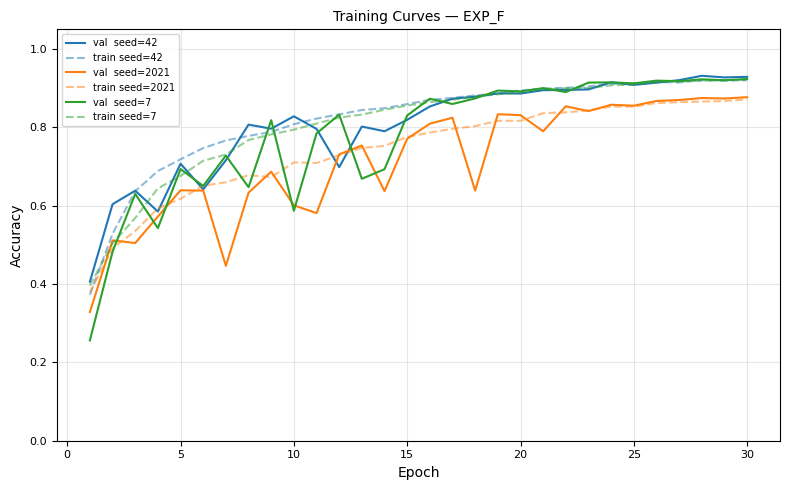

Saved: /kaggle/working/Quantum-Geoscience/figures/fig3_exp_f_training_curves.pdf


In [54]:
# =============================================================================
# SECTION 16 — CELL 16.2: Training Curves
# =============================================================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
_colors = ["tab:blue", "tab:orange", "tab:green"]
for seed, col in zip(CONFIG["ensemble_seeds"], _colors):
    lg = RAW_RESULTS.get(EXPERIMENT_ID, {}).get(seed, {}).get("training_log", [])
    if not lg: continue
    eps  = [e["epoch"]     for e in lg]
    vacc = [e["val_acc"]   for e in lg]
    tacc = [e["train_acc"] for e in lg]
    ax.plot(eps, vacc,  color=col, label=f"val  seed={seed}")
    ax.plot(eps, tacc,  color=col, linestyle="--", alpha=0.5, label=f"train seed={seed}")

ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1.05)
ax.set_title(f"Training Curves — {EXPERIMENT_ID.upper()}")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.tight_layout()
_p = os.path.join(CONFIG["figures_dir"], f"fig3_{EXPERIMENT_ID}_training_curves.pdf")
plt.savefig(_p, dpi=CONFIG["figure_dpi"], bbox_inches="tight"); plt.show()
print(f"Saved: {_p}")


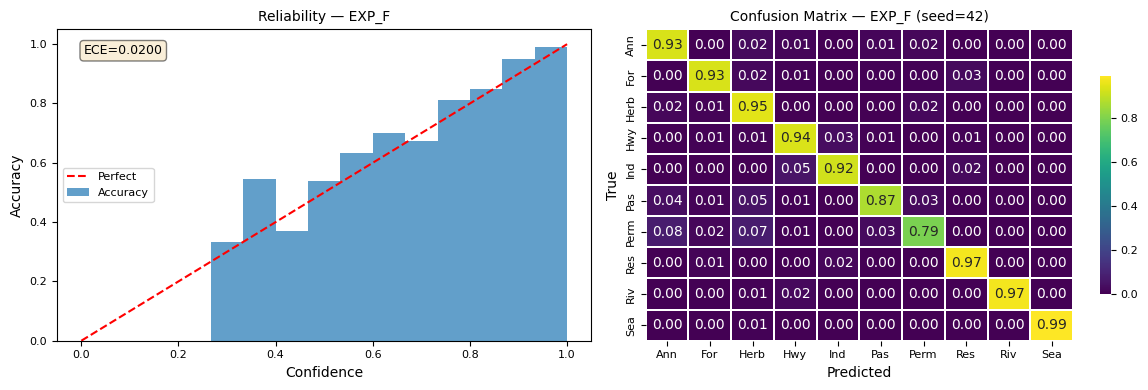

Saved: /kaggle/working/Quantum-Geoscience/figures/fig4_exp_f_reliability_confusion.pdf


In [55]:
# =============================================================================
# SECTION 16 — CELL 16.3: Reliability Diagram + Confusion Matrix
# =============================================================================
import matplotlib.pyplot as plt, numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

@torch.no_grad()
def get_calibration_data(exp_id, seed=42):
    ckpt = get_best_checkpoint(exp_id, seed)
    if not ckpt: return None, None
    m = build_model(exp_id); load_checkpoint(m, ckpt); m.eval()
    all_probs, all_labels = [], []
    for rgb, nir, lbl in test_loader:
        pr = torch.softmax(m(rgb.cuda(), nir.cuda()), dim=1).cpu()
        all_probs.append(pr); all_labels.append(lbl)
    del m; torch.cuda.empty_cache(); gc.collect()
    return torch.cat(all_probs), torch.cat(all_labels)

_bins = np.linspace(0, 1, CONFIG["ece_n_bins"] + 1)
_bc   = (_bins[:-1] + _bins[1:]) / 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

probs, labels = get_calibration_data(EXPERIMENT_ID)
if probs is not None:
    conf    = probs.max(1).values.numpy()
    pred    = probs.argmax(1).numpy()
    correct = (pred == labels.numpy()).astype(float)
    acc_b, conf_b = [], []
    for lo, hi in zip(_bins[:-1], _bins[1:]):
        mask = (conf >= lo) & (conf < hi)
        acc_b.append(correct[mask].mean() if mask.sum() > 0 else 0)
        conf_b.append(conf[mask].mean()   if mask.sum() > 0 else (lo+hi)/2)
    axes[0].bar(_bc, acc_b, width=1/CONFIG["ece_n_bins"], alpha=0.7, label="Accuracy")
    axes[0].plot([0,1],[0,1],"r--",label="Perfect")
    axes[0].set_title(f"Reliability — {EXPERIMENT_ID.upper()}")
    axes[0].set_xlabel("Confidence"); axes[0].set_ylabel("Accuracy"); axes[0].legend()
    _ece_val = RAW_RESULTS.get(EXPERIMENT_ID, {}).get(42, {}).get("uncertainty", {}).get("ece", float("nan"))
    axes[0].text(0.05, 0.92, f"ECE={_ece_val:.4f}", transform=axes[0].transAxes,
                 fontsize=9, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
else:
    axes[0].set_title(f"{EXPERIMENT_ID.upper()} (no checkpoint)")

if probs is not None:
    _p_np = probs.argmax(1).numpy(); _l_np = labels.numpy()
    cm = confusion_matrix(_l_np, _p_np, normalize="true")
    _cls_short = ["Ann","For","Herb","Hwy","Ind","Pas","Perm","Res","Riv","Sea"]
    sns.heatmap(cm, annot=True, fmt=".2f", ax=axes[1], cmap="viridis",
                xticklabels=_cls_short, yticklabels=_cls_short,
                linewidths=0.3, cbar_kws={"shrink": 0.7})
    axes[1].set_title(f"Confusion Matrix — {EXPERIMENT_ID.upper()} (seed=42)")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
else:
    axes[1].set_title(f"{EXPERIMENT_ID.upper()} (no checkpoint)")

plt.tight_layout()
_p = os.path.join(CONFIG["figures_dir"], f"fig4_{EXPERIMENT_ID}_reliability_confusion.pdf")
plt.savefig(_p, dpi=CONFIG["figure_dpi"], bbox_inches="tight"); plt.show()
print(f"Saved: {_p}")


---
# Section 17 — Export and Reproducibility Report: EXP_F


In [56]:
# =============================================================================
# SECTION 17 — CELL 17.1: Save All Exports — EXP_F
# =============================================================================
assert "RAW_RESULTS" in globals(), "Run Section 14 first."

save_json({
    "raw_results":      RAW_RESULTS,
    "ensemble_results": ENSEMBLE_RESULTS,
    "ood_results":      OOD_RESULTS,
    "hessian_results":  HESSIAN_RESULTS,
}, os.path.join(CONFIG["exports_dir"], "metrics.json"))
print("metrics.json saved.")

save_json({
    "experiment":      EXPERIMENT_ID,
    "run_timestamps":  RUN_TIMESTAMPS,
    "run_durations_h": RUN_DURATIONS,
    "seeds_used":      CONFIG["ensemble_seeds"],
    "notebook_name":   f"Quantum_Geoscience_Experiment_{EXPERIMENT_ID[-1].upper()}.ipynb",
    "mis_version":     "v2.2",
    "completion_time": datetime.now().isoformat(),
}, os.path.join(CONFIG["exports_dir"], "experiment_metadata.json"))
print("experiment_metadata.json saved.")

if HESSIAN_RESULTS:
    save_json(HESSIAN_RESULTS, os.path.join(CONFIG["exports_dir"], "hessian_traces.json"))
    print("hessian_traces.json saved.")

print("All exports written.")


metrics.json saved.
experiment_metadata.json saved.
All exports written.


In [57]:
# =============================================================================
# SECTION 17 — CELL 17.2: ARTIFACT_MANIFEST.txt (SHA-256)
# =============================================================================
import hashlib

def sha256_file(path):
    h = hashlib.sha256()
    with open(path,"rb") as f:
        for chunk in iter(lambda: f.read(65536), b""): h.update(chunk)
    return h.hexdigest()

_manifest_lines = [
    "# Quantum-Geoscience Artifact Manifest",
    f"# Generated: {datetime.now().isoformat()}",
    f"# Experiment: {EXPERIMENT_ID.upper()}",
    f"# MIS: v2.2",
    "",
]
for _dir in [CONFIG["figures_dir"], CONFIG["tables_dir"], CONFIG["exports_dir"]]:
    if not os.path.isdir(_dir): continue
    for _fname in sorted(os.listdir(_dir)):
        _fpath = os.path.join(_dir, _fname)
        if os.path.isfile(_fpath):
            _rel  = os.path.relpath(_fpath, CONFIG["project_root"])
            _hash = sha256_file(_fpath)
            _manifest_lines.append(f"SHA256  {_hash}  {_rel}")

_manifest_path = os.path.join(CONFIG["exports_dir"], "ARTIFACT_MANIFEST.txt")
with open(_manifest_path, "w") as f:
    f.write("\n".join(_manifest_lines))

print(f"ARTIFACT_MANIFEST.txt: {len(_manifest_lines)-5} artifacts hashed.")
print("\n" + "="*60)
print(f"NOTEBOOK {EXPERIMENT_ID.upper()} EXECUTION COMPLETE")
print("="*60)


ARTIFACT_MANIFEST.txt: 7 artifacts hashed.

NOTEBOOK EXP_F EXECUTION COMPLETE
